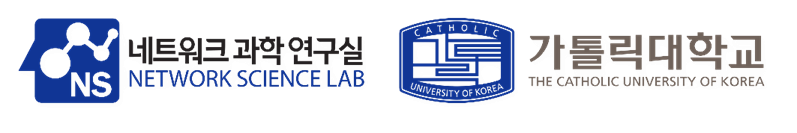

<h1><center><b>💻 Practice 7:</b> </br> Subgraph Mining</center></h1>

## Overview
1. **Graph Isomorphism**: Using GraphMatcher for subgraph detection
2. **gSpan Algorithm**: Frequent subgraph pattern mining on generic graphs
3. **Apriori-based FSG**: Itemset mining on transaction data
4. **SMILES to Graphs**: Converting chemical structures to graph representation
5. **Feature Extraction**: Mining subgraphs as features from molecular graphs
6. **Predictive Modeling**: Building SVR model to predict molecular properties from graph features

## Learning Outcomes
- Understand graph isomorphism and its applications
- Apply gSpan algorithm for frequent subgraph discovery
- Convert chemical notation (SMILES) to computational graphs
- Build and evaluate machine learning models on graph-based features

---

# 1. Testing if two graphs are isomorphic

Returns True if the graphs G1 and G2 are isomorphic and False otherwise

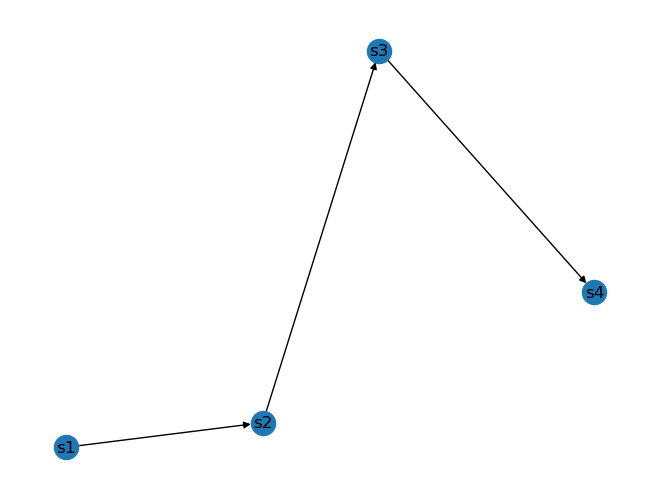

In [1]:
import networkx as nx

G1, G2 = nx.DiGraph(), nx.DiGraph()
G1.add_edges_from([("s1", "s2"), ("s2", "s3"), ("s3", "s4")]) # G1: 1->2->3->4
G2.add_edges_from([("s1", "s2"), ("s2", "s3"), ("s3", "s7")]) # G2: 1->2->3->7

nx.draw(G1, with_labels = True)

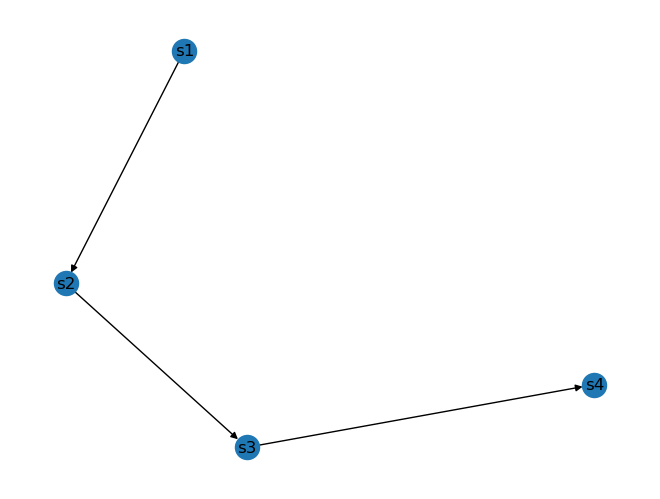

In [2]:
nx.draw(G1, with_labels = True)

In [3]:
nx.is_isomorphic(G1, G2)

True

## 1.1. Uses the VF2 Algorithm (An implementation of VF2 algorithm for graph ismorphism testing)



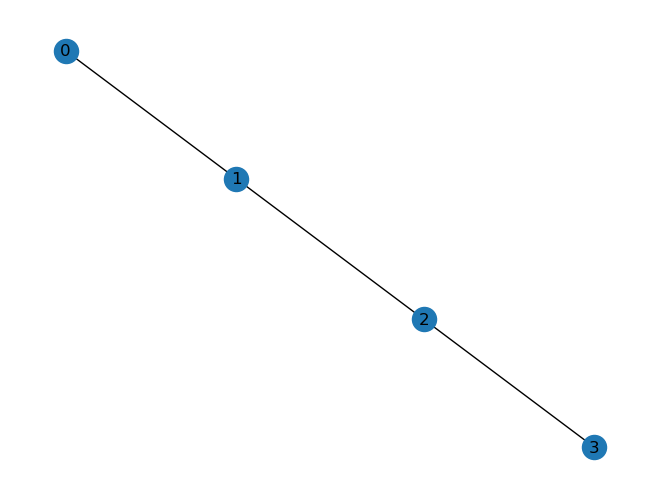

In [4]:
#Create graph G1 and G2
from networkx.algorithms import isomorphism
G1 = nx.path_graph(4)
G2 = nx.path_graph(4)

nx.draw(G1, with_labels = True)

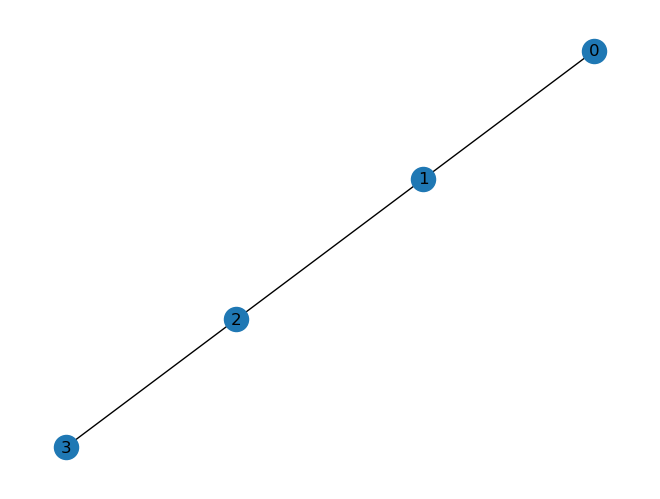

In [5]:
nx.draw(G2, with_labels = True)

In [6]:
GM = isomorphism.GraphMatcher(G1,G2)
GM.is_isomorphic()

True

In [7]:
GM.mapping

{0: 0, 1: 1, 2: 2, 3: 3}

## 1.2. Suppose G1 and G2 are isomorphic directed graphs. 
## Verification is as follows:

In [8]:
#path_graph to generates a linearly connected graph with 4 nodes
G1 = nx.path_graph(4, create_using=nx.DiGraph())
G2 = nx.path_graph(4, create_using=nx.DiGraph())
#DiGraphMatcher class from isomorphism module to create a DiGraphMatcher object
DiGM = isomorphism.DiGraphMatcher(G1,G2)
DiGM.is_isomorphic()

True

### DiGM.mapping stores the isomorphism mapping from G1 to G2


In [9]:
DiGM.mapping

{0: 0, 1: 1, 2: 2, 3: 3}

## 1.3. Label attributes comparison: 
## During comparison, node attributes are compared

By default, node attributes are a blank dictionary (and do not incorporate node label information)

A quick way to fix that is to use nx.convert_node_labels_to_integers and specify the key for label attributes:

In [10]:
# Convert node labels to integers while preserving original labels as attributes
# This allows us to match nodes based on their label attribute values

G1_int = nx.convert_node_labels_to_integers(G1, label_attribute='label')
G2_int = nx.convert_node_labels_to_integers(G2, label_attribute='label')

# Display the label attribute of the first node
print("Node 0 attributes:")
print(G1_int.nodes[0])

Node 0 attributes:
{'label': 0}


In [11]:
nx.is_isomorphic(G1_int, G2_int, node_match = lambda x,y: x==y)

True

## 1.4. Search for a subgraph of G2 that is isomorphic to G1
## (Finding multiple subgraphs)

In [12]:
import networkx.algorithms.isomorphism as iso

# Define pattern graph (small graph to search for)
pattern_graph = nx.Graph()
pattern_graph.add_edges_from([(1, 2)])  # Simple 2-node, 1-edge pattern

# Define target graph (larger graph to search in)
target_graph = nx.Graph()
target_graph.add_edges_from([(1, 2), (2, 3), (3, 4)])  # Path of 4 nodes

# Create a matcher to find all occurrences of pattern_graph in target_graph
graph_matcher = iso.GraphMatcher(target_graph, pattern_graph)

# Find all possible mappings of pattern_graph within target_graph
print("All subgraph isomorphisms found:")
print("(target_node -> pattern_node mapping)\n")

subgraph_count = 0
for mapping in graph_matcher.subgraph_isomorphisms_iter():
    subgraph_count += 1
    print(f"Isomorphism {subgraph_count}: {mapping}")

print(f"\nTotal isomorphisms found: {subgraph_count}")

All subgraph isomorphisms found:
(target_node -> pattern_node mapping)

Isomorphism 1: {1: 1, 2: 2}
Isomorphism 2: {2: 1, 1: 2}
Isomorphism 3: {2: 1, 3: 2}
Isomorphism 4: {3: 1, 2: 2}
Isomorphism 5: {3: 1, 4: 2}
Isomorphism 6: {4: 1, 3: 2}

Total isomorphisms found: 6


## 1.5. Using GraphMatcher to find a subgraph in Karate network

Modify the GraphMatcher class so that subgraph_is_isomorphic() will determine whether G2 is a subgraph (with
an identity isomorphism).

In [13]:
class GraphMatcher(nx.algorithms.isomorphism.GraphMatcher):
    def semantic_feasibility(self, G1_node, G2_node):
        return G1_node == G2_node

In [14]:
G = nx.karate_club_graph()

# Grab a subgraph
subG_good = G.subgraph(range(10))

    
# Make an isomorphic subgraph
subG_bad = nx.relabel_nodes(subG_good, dict(zip(range(10), 'abcdefghij')))

gm = GraphMatcher(G,subG_good)
gm.subgraph_is_isomorphic()


True

In [15]:
gm = GraphMatcher(G,subG_bad)
gm.subgraph_is_isomorphic()


False

# 2. gSpan method

In this section, we will use the **gSpan** algorithm to find frequent subgraphs. 
Ensure you have installed the required libraries before proceeding.

In [3]:
# Make sure your environment has gspan-mining installed
# !pip install gspan-mining
from gspan_mining.config import parser
from gspan_mining.main import main

In [4]:
%matplotlib inline

In [ ]:
# Note: Use given ./gspan_mining/graph.py

## 2.1. Finding a subgraph with min support (-s 2) and minimal nodes in the subgraph (-l 3)

### Overview
This section demonstrates the gSpan algorithm for frequent subgraph mining on an undirected graph dataset.

### Data File Format

The input data follows the gSpan format:
- **"t # N"**: Declaration of the Nth graph
- **"v M L"**: Vertex M in the current graph has label L
- **"e P Q L"**: Edge between vertices P and Q with label L

### Parameters Explained
- **-s 2**: Minimum support threshold (subgraph must appear in at least 2 graphs)
- **-l 3**: Minimum number of nodes required in a frequent subgraph
- **-p True**: Enable printing of results

In [6]:
args_str = '-s 2 -l 3 -p True ./graphdata/sample_data4'
FLAGS, _ = parser.parse_known_args(args=args_str.split())

## 2.2. Getting all the subgraph with minimal support

t # 0
v 0 A
v 1 B
v 2 C
e 0 1 1
e 1 2 1

Support: 3


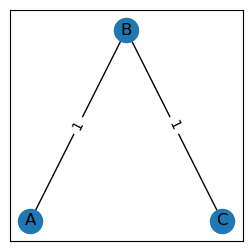


-----------------

t # 1
v 0 A
v 1 B
v 2 C
e 0 1 1
e 0 2 1
e 1 2 1

Support: 2


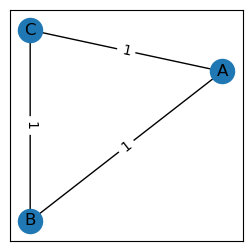


-----------------

t # 2
v 0 A
v 1 B
v 2 C
v 3 A
e 0 1 1
e 1 2 1
e 2 3 1

Support: 2


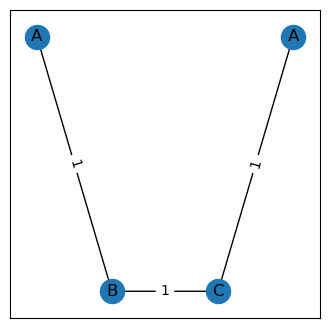


-----------------

t # 3
v 0 A
v 1 B
v 2 A
e 0 1 1
e 1 2 1

Support: 3


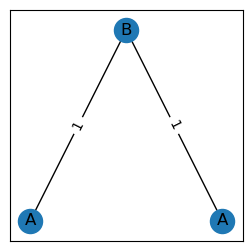


-----------------

t # 4
v 0 A
v 1 B
v 2 A
v 3 C
e 0 1 1
e 1 2 1
e 1 3 1

Support: 3


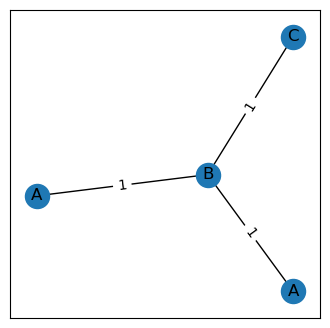


-----------------

t # 5
v 0 A
v 1 B
v 2 A
v 3 C
e 0 1 1
e 1 2 1
e 2 3 1

Support: 2


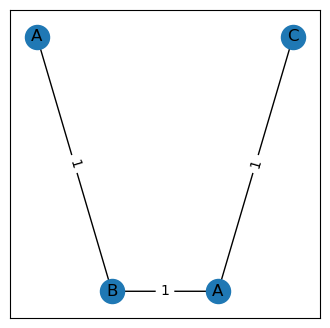


-----------------

t # 6
v 0 A
v 1 B
v 2 A
v 3 C
e 0 1 1
e 1 2 1
e 1 3 1
e 2 3 1

Support: 2


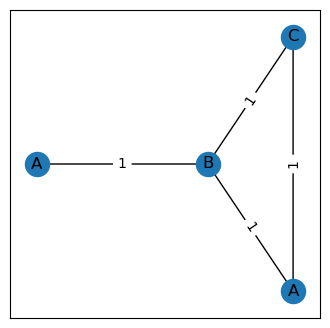


-----------------

t # 7
v 0 A
v 1 B
v 2 C
e 0 1 1
e 0 2 1

Support: 2


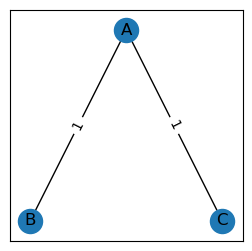


-----------------

t # 8
v 0 A
v 1 A
v 2 B
e 0 1 1
e 1 2 1

Support: 3


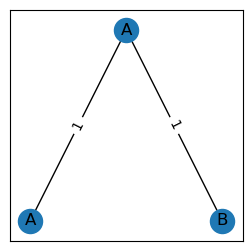


-----------------

t # 9
v 0 A
v 1 A
v 2 B
e 0 1 1
e 0 2 1
e 1 2 1

Support: 3


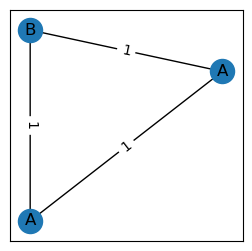


-----------------

t # 10
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 0 2 1
e 1 2 1
e 2 3 1

Support: 3


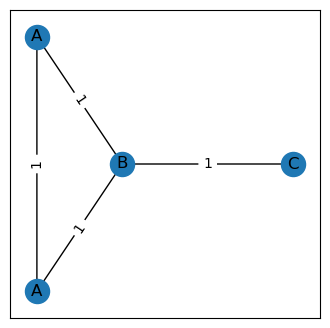


-----------------

t # 11
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 0 2 1
e 0 3 1
e 1 2 1
e 2 3 1

Support: 2


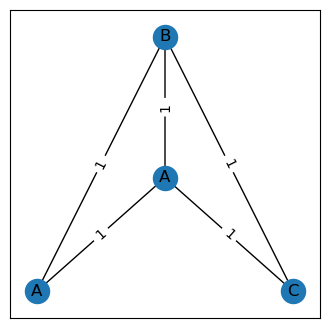


-----------------

t # 12
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 0 2 1
e 1 2 1
e 1 3 1

Support: 2


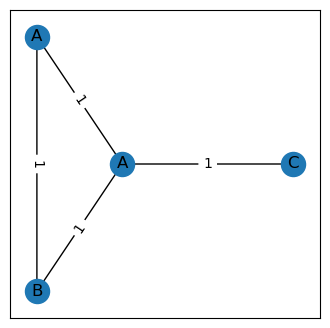


-----------------

t # 13
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 1 2 1
e 2 3 1

Support: 3


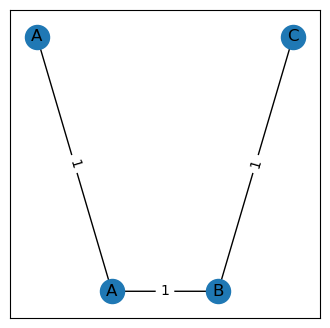


-----------------

t # 14
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 0 3 1
e 1 2 1
e 2 3 1

Support: 2


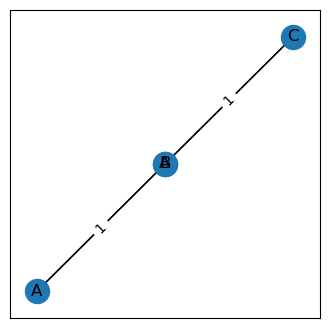


-----------------

t # 15
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 1 2 1
e 1 3 1
e 2 3 1

Support: 2


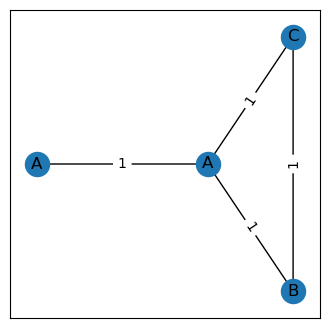


-----------------

t # 16
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 1 2 1
e 1 3 1

Support: 2


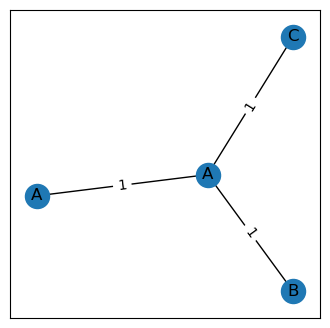


-----------------

t # 17
v 0 A
v 1 A
v 2 B
v 3 C
e 0 1 1
e 0 3 1
e 1 2 1

Support: 2


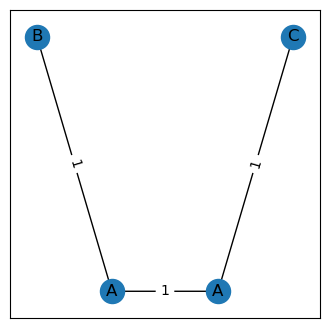


-----------------

t # 18
v 0 A
v 1 A
v 2 C
e 0 1 1
e 1 2 1

Support: 2


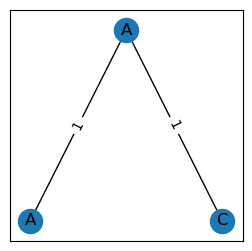


-----------------

t # 19
v 0 A
v 1 A
v 2 C
v 3 B
e 0 1 1
e 1 2 1
e 2 3 1

Support: 2


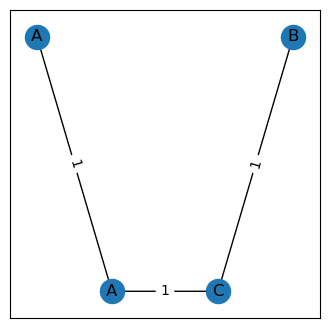


-----------------

t # 20
v 0 A
v 1 C
v 2 B
e 0 1 1
e 1 2 1

Support: 2


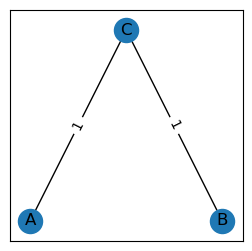


-----------------

Read:	0.01 s
Mine:	2.18 s
Total:	2.19 s


In [7]:
gs = main(FLAGS)
print(gs)

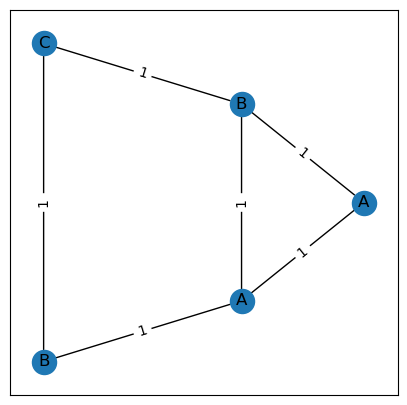

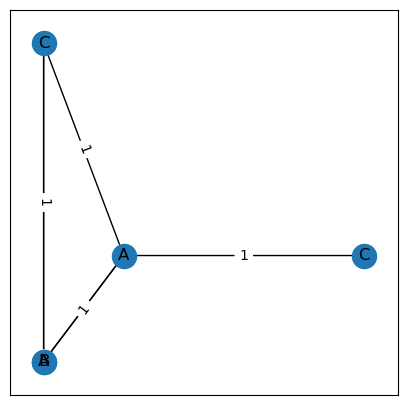

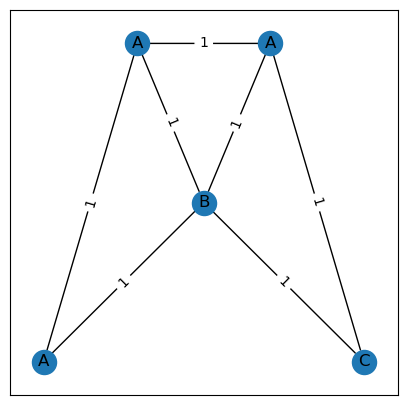

In [8]:
for g in gs.graphs.values():
    g.plot()

## 3. Apriori-based Frequent Subgraph Mining (FSG Algorithm)

In this section, we apply the **apriori-based FSG (Frequent Subgraph) algorithm** to mine frequent patterns from transaction data.

### About the FP-Growth Algorithm
FP-Growth (Frequent Pattern Growth) is an efficient algorithm that builds an FP-tree structure to avoid generating candidate itemsets. This is more efficient than the classical Apriori approach.

**Key Parameters:**
- **min_support**: Minimum relative frequency threshold (0-1 scale) for a pattern to be considered frequent
- **use_colnames**: If True, uses original column names instead of numeric indices in output

In [9]:
# !pip install mlxtend

In [10]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

# Define the list of transactions (subgraphs)
transactions = [
    ['A', 'B', 'C'],
    ['B', 'C', 'D'],
    ['A', 'C', 'D'],
    ['B', 'D'],
    ['A', 'C'],
    ['B', 'C'],
    ['A', 'B', 'D']
]

# Initialize the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert the encoded transactions to a DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# Apply the apriori-based FPGrowth algorithm
frequent_subgraphs = fpgrowth(df, min_support=0.3, use_colnames=True)

# Print the frequent subgraphs
print(frequent_subgraphs)


    support           itemsets
0  0.714286     frozenset({C})
1  0.714286     frozenset({B})
2  0.571429     frozenset({A})
3  0.571429     frozenset({D})
4  0.428571  frozenset({B, C})
5  0.428571  frozenset({A, C})
6  0.428571  frozenset({B, D})


## 4. Converting SMILES Codes to Molecular Graphs

### About SMILES
**SMILES** (Simplified Molecular Input Line Entry System) is a notation for representing chemical structures as strings. For example:
- **CCO** represents ethanol (C-C-O chain)
- **c1ccccc1** represents benzene (6-membered aromatic ring)

### Task
In this section, we will:
1. Load molecular data from a CSV file containing SMILES strings
2. Convert each SMILES string to a NetworkX graph representation
3. Store the molecular graphs for further analysis

Each atom becomes a node (labeled with element symbol), and each bond becomes an edge (labeled with bond type).

In [11]:
!pip install rdkit

/home/linux/miniconda3/envs/GraphMining/lib/python3.14/pty.py:66: DeprecationWarning: This process (pid=11505) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Sample molecule data:
num                                              2
name                          Terbutylchlorambucil
p_np                                             1
smiles    C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
Name: 1, dtype: object

Successfully converted 26 SMILES strings to graphs

Visualizing the first molecular graph:


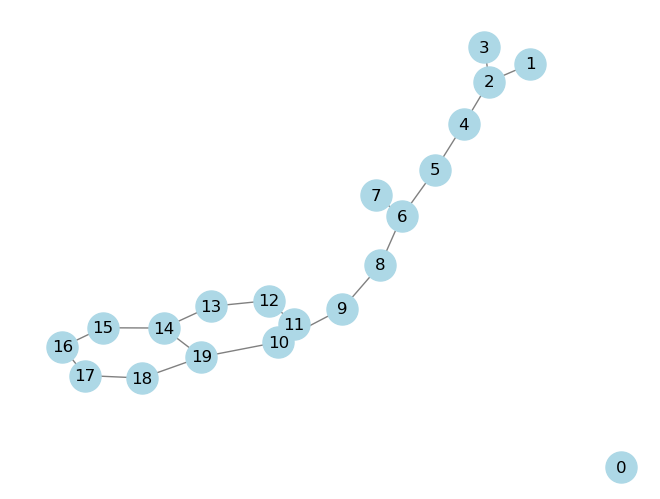

In [12]:
# Convert SMILES strings to molecular graphs
import numpy as np
import pandas as pd
import networkx as nx
from rdkit import Chem
from rdkit import RDLogger

# Suppress RDKit warnings for cleaner output
RDLogger.DisableLog('rdApp.*')

# Load the molecular dataset 
df = pd.read_csv('./graphdata/Molecular_Sample.csv')

# Display the first molecule's data
print("Sample molecule data:")
print(df.iloc[1])
print()

# Convert each SMILES string to a NetworkX graph
graphs = []
for idx, smiles in enumerate(df['smiles']):
    # Parse SMILES string into RDKit molecule object
    mol = Chem.MolFromSmiles(smiles, sanitize=False)
    
    # Create an empty NetworkX graph
    G = nx.Graph()
    
    # Add nodes for each atom with element label
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), element=atom.GetSymbol())
    
    # Add edges for each bond with bond type information
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), 
                   bond_type=str(bond.GetBondType()))
    
    graphs.append(G)

print(f"Successfully converted {len(graphs)} SMILES strings to graphs")
    
# Visualize the first molecular graph
print("\nVisualizing the first molecular graph:")
nx.draw(graphs[0], with_labels=True, node_color='lightblue', 
        edge_color='gray', node_size=500)

In [13]:
import networkx as nx
import os

# Create output directory if it doesn't exist
output_dir = "./graphdata/test/"
os.makedirs(output_dir, exist_ok=True)

# Convert each graph to adjacency list format and save to file
for i, graph in enumerate(graphs):
    # Construct full file path for the current graph
    file_path = os.path.join(output_dir, f"graph{i}.txt")
    
    # Write graph as adjacency list (node followed by its neighbors)
    nx.write_adjlist(graph, file_path)
    
    # Read the file and remove RDKit comment lines (lines starting with '#')
    with open(file_path, "r") as file:
        lines = file.readlines()
    
    # Filter out comment lines
    lines = [line for line in lines if not line.startswith('#')]
    
    # Write back the cleaned content
    with open(file_path, "w") as file:
        file.writelines(lines)

print(f"Successfully saved {len(graphs)} graphs to {output_dir}")

Successfully saved 26 graphs to ./graphdata/test/


In [14]:
import os

# Define the directory where the graph files are located
graph_directory = './graphdata/test/'

# Get a list of all graph files and sort by graph index
graph_file_names = [f for f in os.listdir(graph_directory) if f.startswith('graph') and f.endswith('.txt')]
graph_file_names.sort(key=lambda x: int(x[5:-4]))  # Extract number from filename and sort numerically

# Create comprehensive node label set (A-Z, then AA-ZZ, etc.)
node_labels = (
    [chr(i) for i in range(ord('A'), ord('Z')+1)] +  # A to Z
    [chr(i)+chr(j) for i in range(ord('A'), ord('Z')+1) 
     for j in range(ord('A'), ord('Z')+1)]  # AA to ZZ
)

# Define output file path for gSpan format
output_file_path = './graphdata/test/output'

# Convert adjacency list format to gSpan format
with open(output_file_path, 'w') as outfile:
    # Process each graph file
    for graph_index, graph_file_name in enumerate(graph_file_names):
        # Read the adjacency list representation
        with open(os.path.join(graph_directory, graph_file_name), 'r') as infile:
            lines = infile.readlines()

        # Parse the adjacency list format (node followed by its neighbors)
        adjacency_dict = {}
        for line in lines:
            parts = list(map(int, line.split()))
            node = parts[0]
            neighbors = parts[1:] if len(parts) > 1 else []
            adjacency_dict[node] = neighbors

        # Write graph header with unique identifier
        outfile.write(f"t # {graph_index}\n")
        
        # Write all vertices with their labels
        for node in sorted(adjacency_dict.keys()):
            if node < len(node_labels):  # Ensure label exists
                outfile.write(f"v {node} {node_labels[node]}\n")
            else:
                outfile.write(f"v {node} X\n")  # Default label if out of range

        # Write all edges (avoid duplicates by only writing if node < neighbor)
        written_edges = set()
        for node in sorted(adjacency_dict.keys()):
            for neighbor in adjacency_dict[node]:
                # Create edge pair in canonical form (smaller index first)
                edge_pair = tuple(sorted([node, neighbor]))
                if edge_pair not in written_edges:
                    outfile.write(f"e {node} {neighbor} 1\n")  # Edge weight = 1
                    written_edges.add(edge_pair)

print(f"Successfully converted {len(graph_file_names)} graphs to gSpan format")

Successfully converted 26 graphs to gSpan format


## 5. Applying gspan algorithm to find frequent subgraph mining

t # 0
v 0 B
v 1 C
v 2 D
e 0 1 1
e 1 2 1

Support: 17


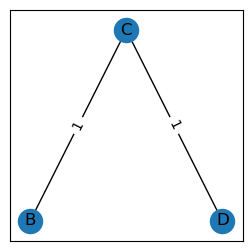


-----------------

t # 1
v 0 E
v 1 F
v 2 G
e 0 1 1
e 1 2 1

Support: 20


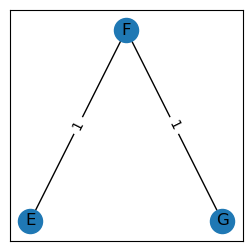


-----------------

t # 2
v 0 E
v 1 F
v 2 G
v 3 H
e 0 1 1
e 1 2 1
e 2 3 1

Support: 17


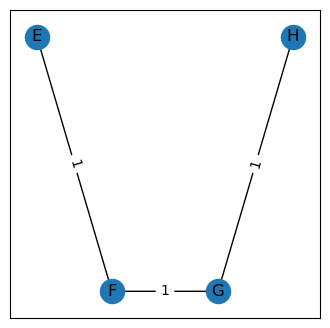


-----------------

t # 3
v 0 F
v 1 G
v 2 H
e 0 1 1
e 1 2 1

Support: 19


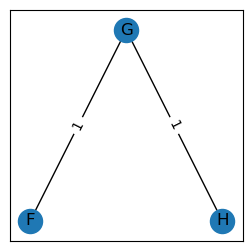


-----------------

t # 4
v 0 G
v 1 H
v 2 I
e 0 1 1
e 1 2 1

Support: 17


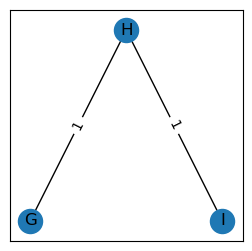


-----------------

t # 5
v 0 I
v 1 J
v 2 K
e 0 1 1
e 1 2 1

Support: 19


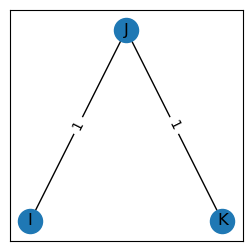


-----------------

t # 6
v 0 I
v 1 J
v 2 K
v 3 L
e 0 1 1
e 1 2 1
e 2 3 1

Support: 17


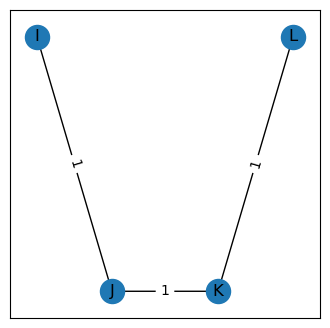


-----------------

t # 7
v 0 J
v 1 K
v 2 L
e 0 1 1
e 1 2 1

Support: 19


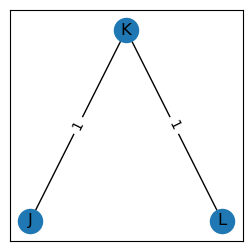


-----------------

t # 8
v 0 R
v 1 S
v 2 T
e 0 1 1
e 1 2 1

Support: 15


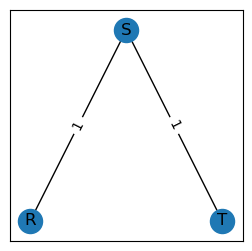


-----------------

t # 9
v 0 A
v 1 B
v 2 C
e 0 1 1
e 1 2 1

Support: 23


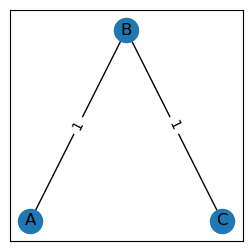


-----------------

t # 10
v 0 A
v 1 B
v 2 C
v 3 D
e 0 1 1
e 1 2 1
e 2 3 1

Support: 16


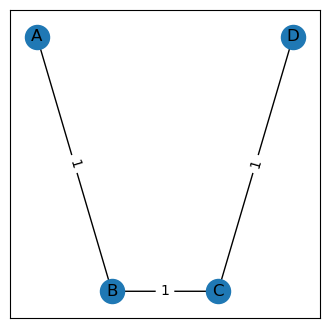


-----------------

t # 11
v 0 D
v 1 E
v 2 F
e 0 1 1
e 1 2 1

Support: 19


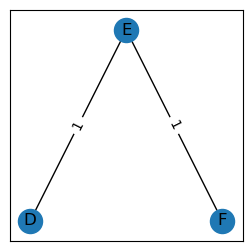


-----------------

t # 12
v 0 D
v 1 E
v 2 F
v 3 G
e 0 1 1
e 1 2 1
e 2 3 1

Support: 17


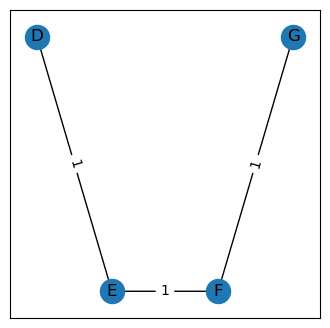


-----------------

t # 13
v 0 H
v 1 I
v 2 J
e 0 1 1
e 1 2 1

Support: 17


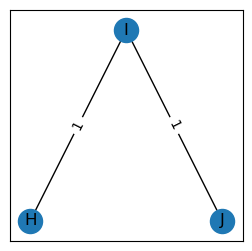


-----------------

Read:	0.01 s
Mine:	1.72 s
Total:	1.73 s
{0: <gspan_mining.graph.Graph object at 0x7185c20deba0>, 1: <gspan_mining.graph.Graph object at 0x7185c21516d0>, 2: <gspan_mining.graph.Graph object at 0x7185c2151810>, 3: <gspan_mining.graph.Graph object at 0x7185c1fb4770>, 4: <gspan_mining.graph.Graph object at 0x7185c1fb48a0>, 5: <gspan_mining.graph.Graph object at 0x7185c211dd90>, 6: <gspan_mining.graph.Graph object at 0x7185c21279b0>, 7: <gspan_mining.graph.Graph object at 0x7185c2127ac0>, 8: <gspan_mining.graph.Graph object at 0x7185c2191350>, 9: <gspan_mining.graph.Graph object at 0x7185c2191d50>, 10: <gspan_mining.graph.Graph object at 0x7185c21ace60>, 11: <gspan_mining.graph.Graph object at 0x7185c21acf50>, 12: <gspan_mining.graph.Graph object at 0x7185c2019470>, 13: <gspan_mining.graph.Graph object at 0x7185c201b070>, 14: <gspan_mining.graph.Graph object at 0x7185c21768f0>, 15: <gspan_mining.graph.Graph object at 0x7185c2105c10>, 16: <gspan_mining.graph.Graph object 

In [4]:
args_str = '-s 15 -l 3 -p True ./graphdata/test/output'
FLAGS, _ = parser.parse_known_args(args=args_str.split())

gs = main(FLAGS)
# The frequent subgraphs are stored in gs.graphs
frequent_subgraphs = gs.graphs
print(gs)
print(frequent_subgraphs)

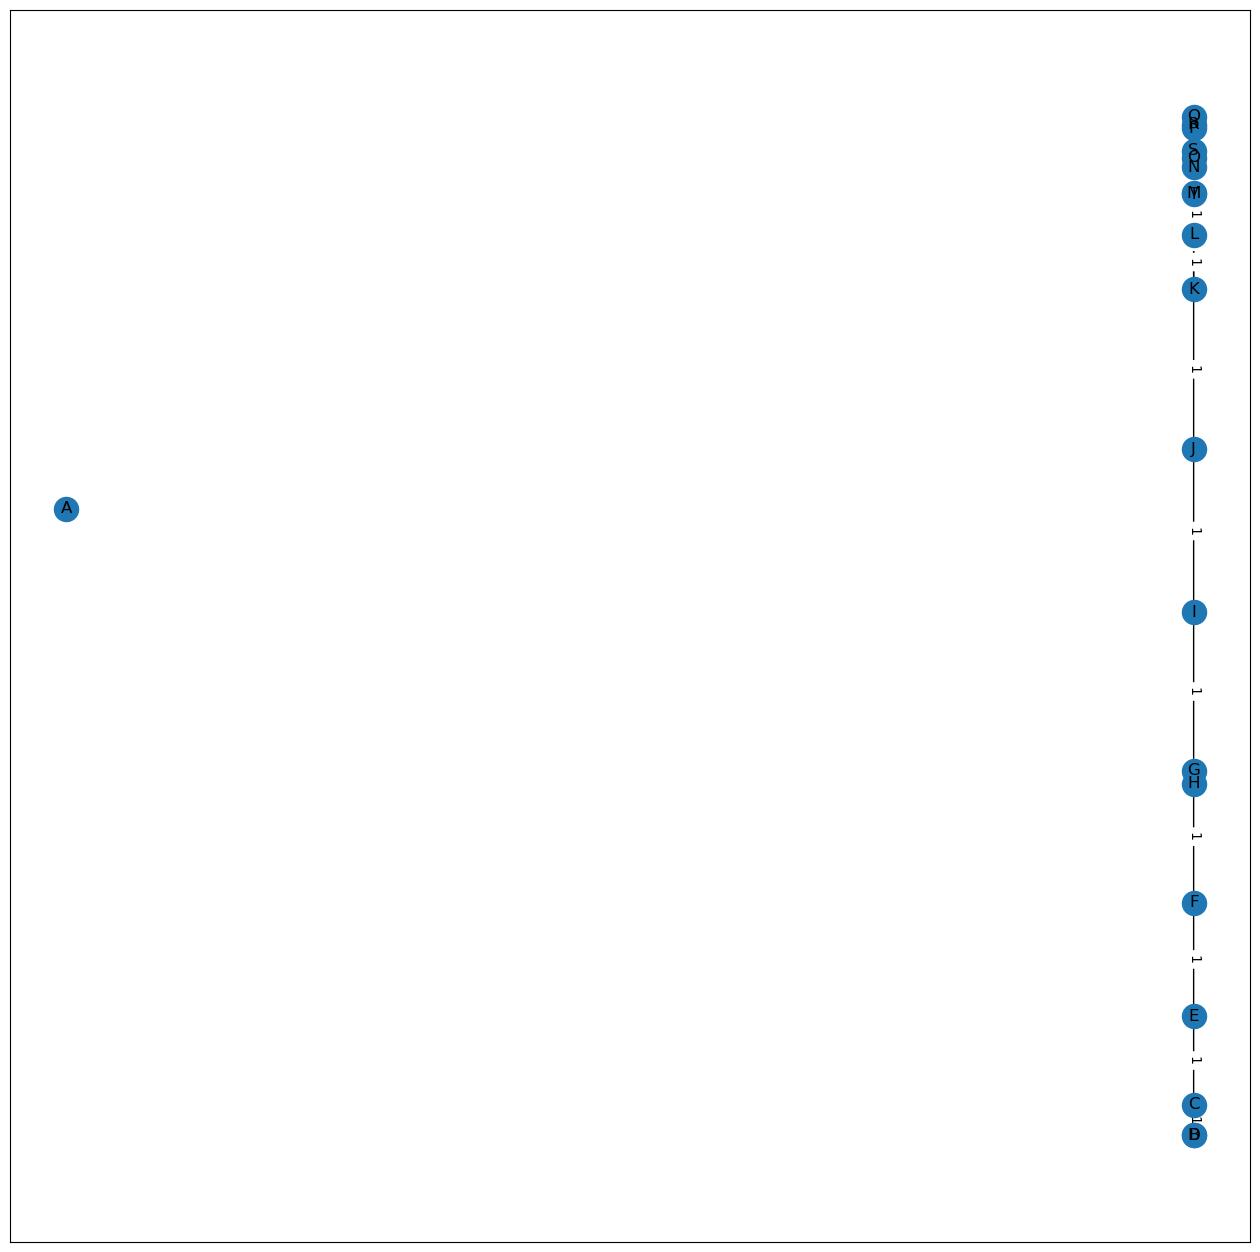

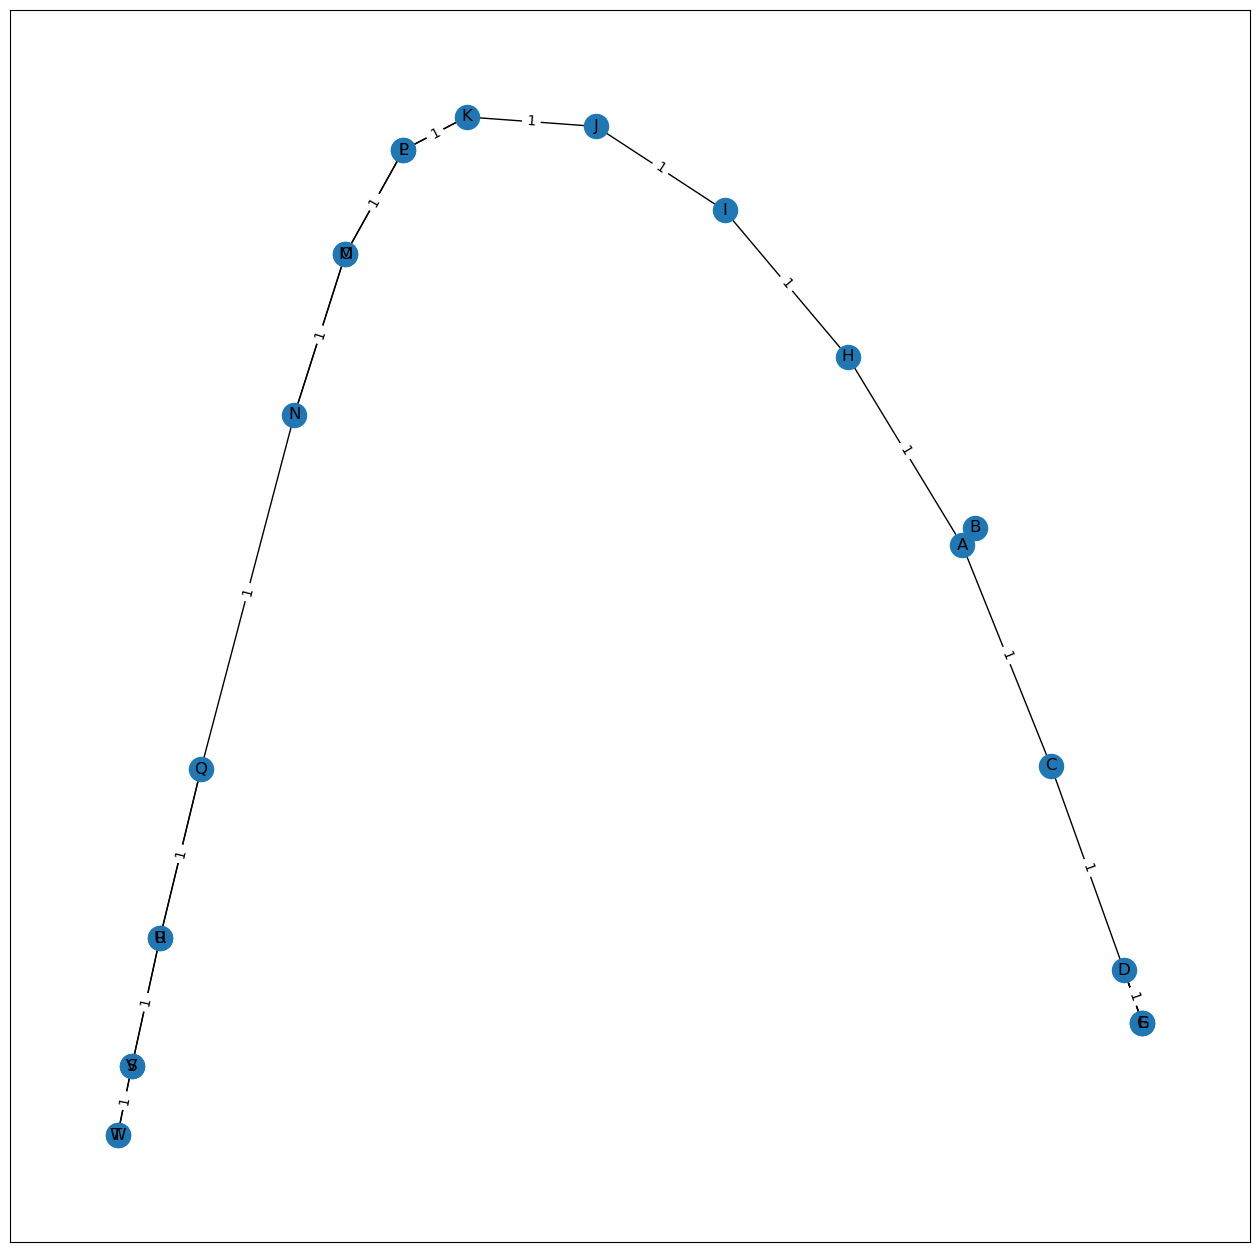

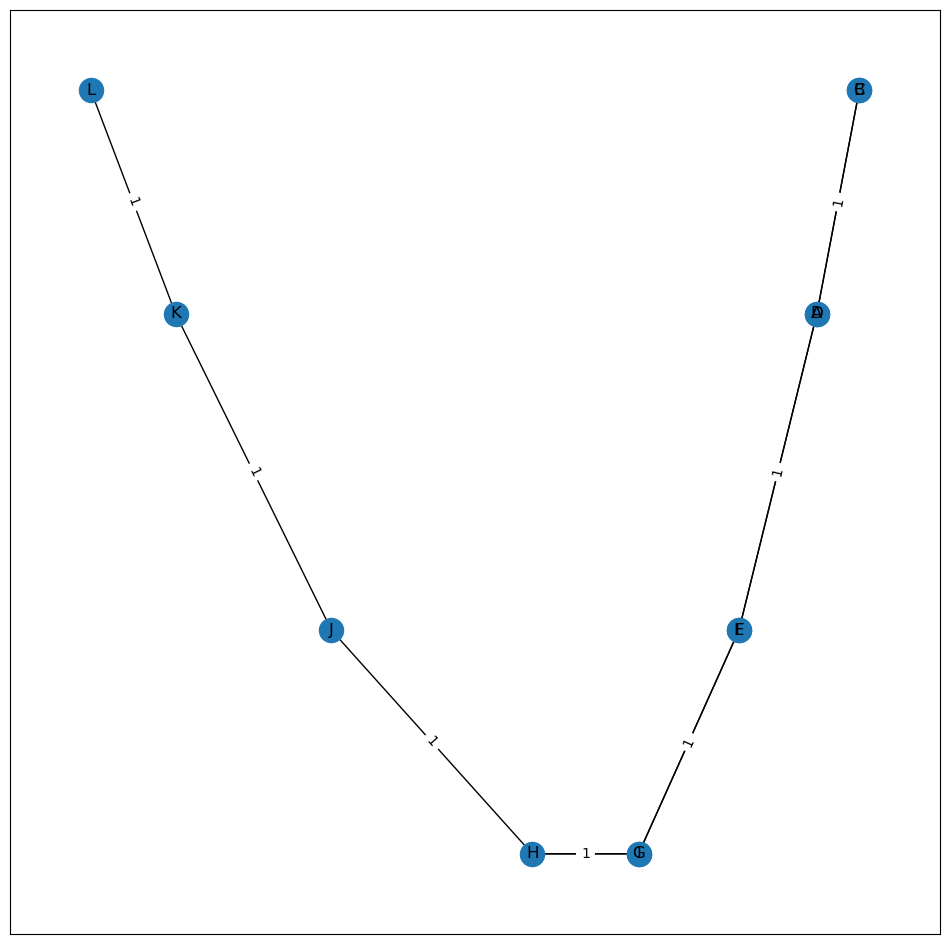

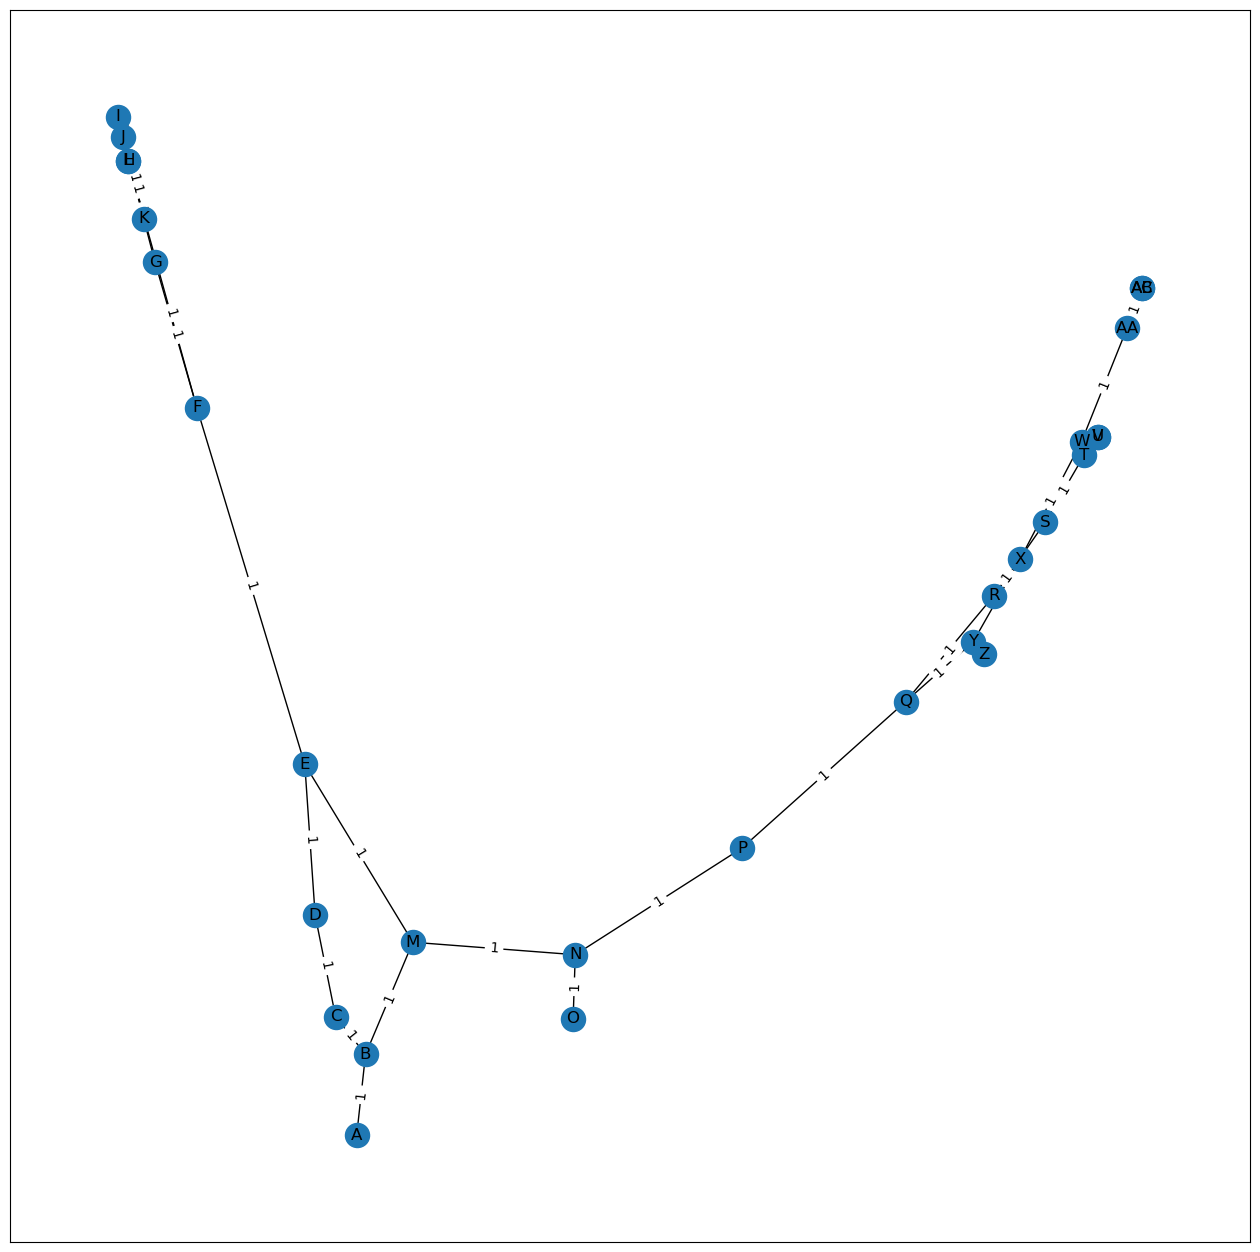

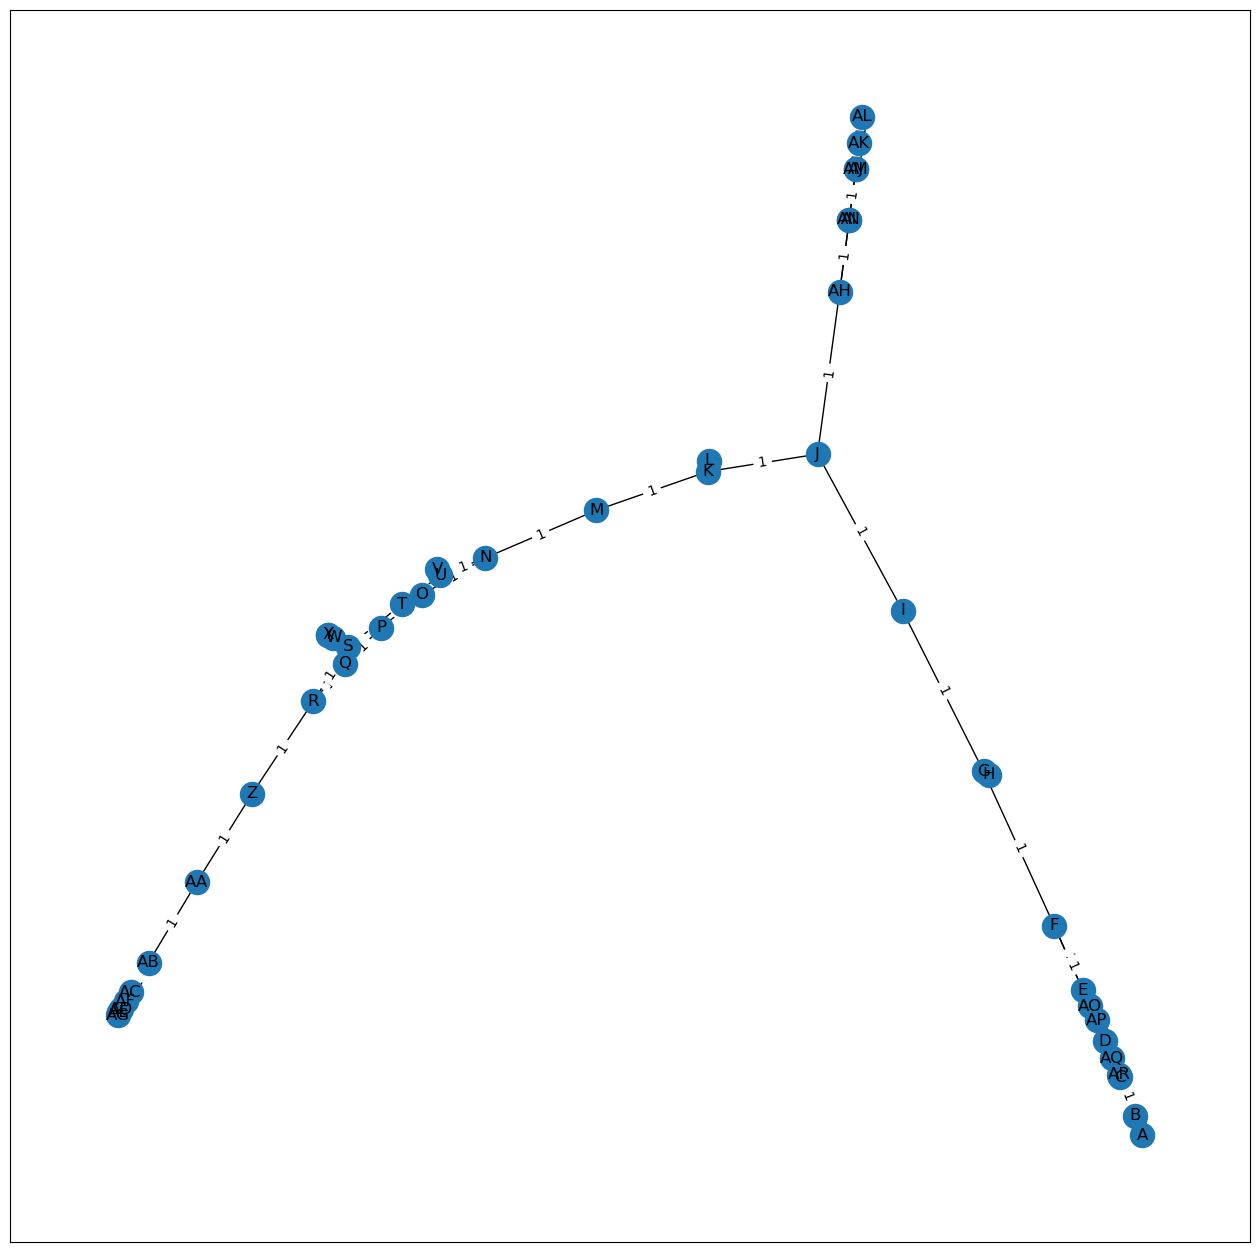

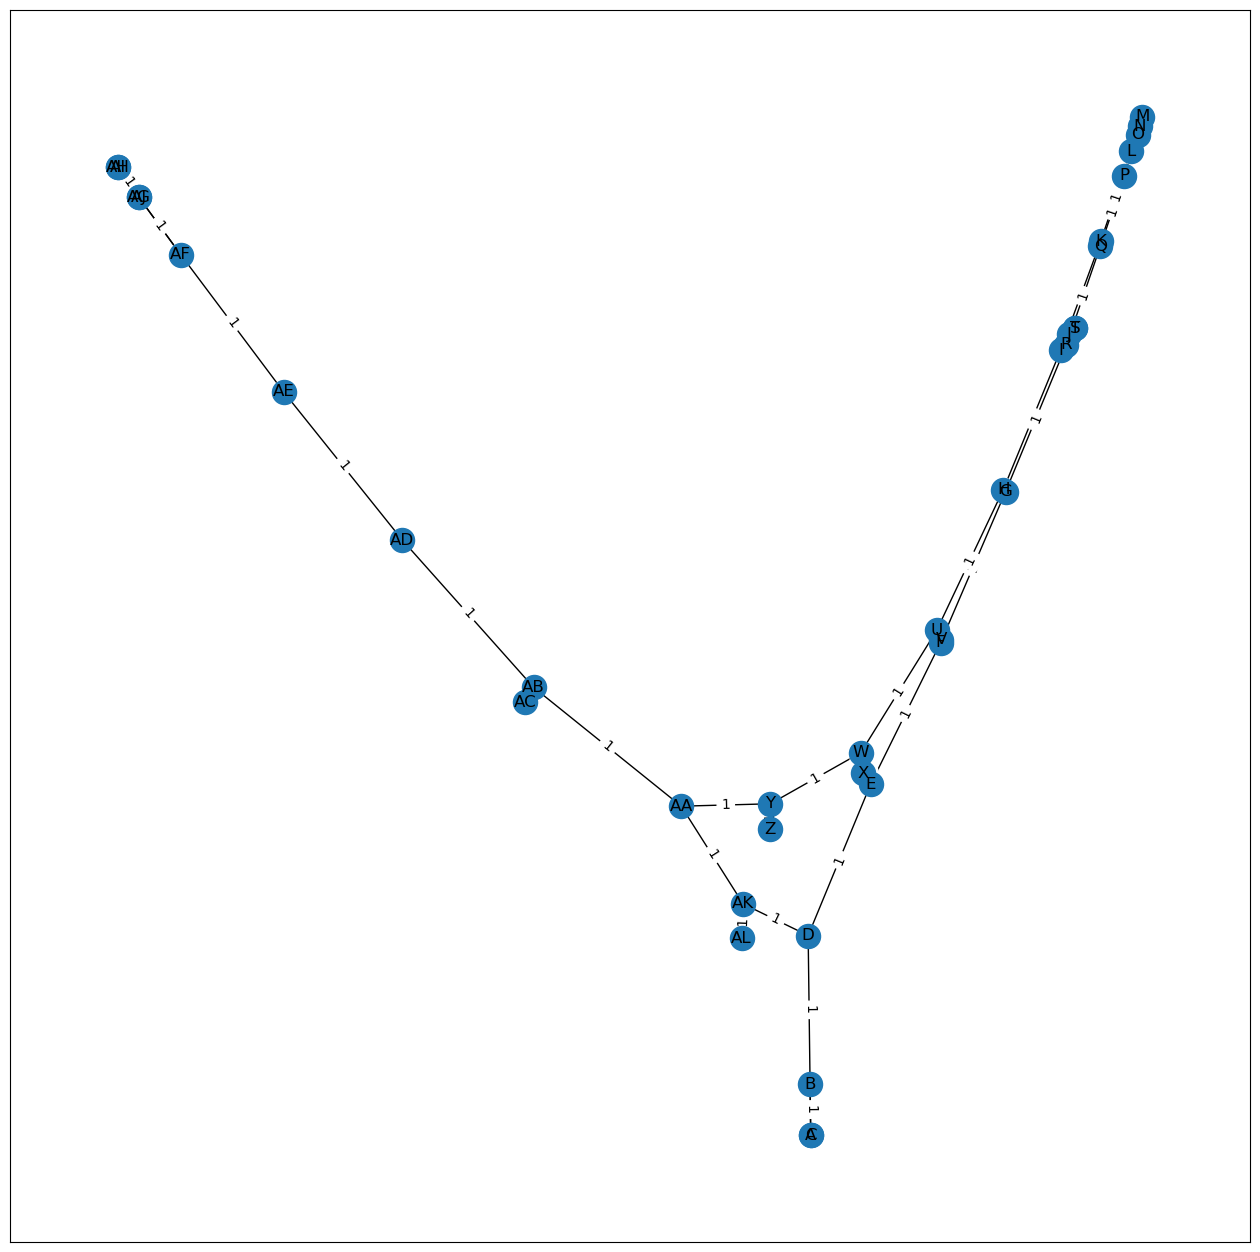

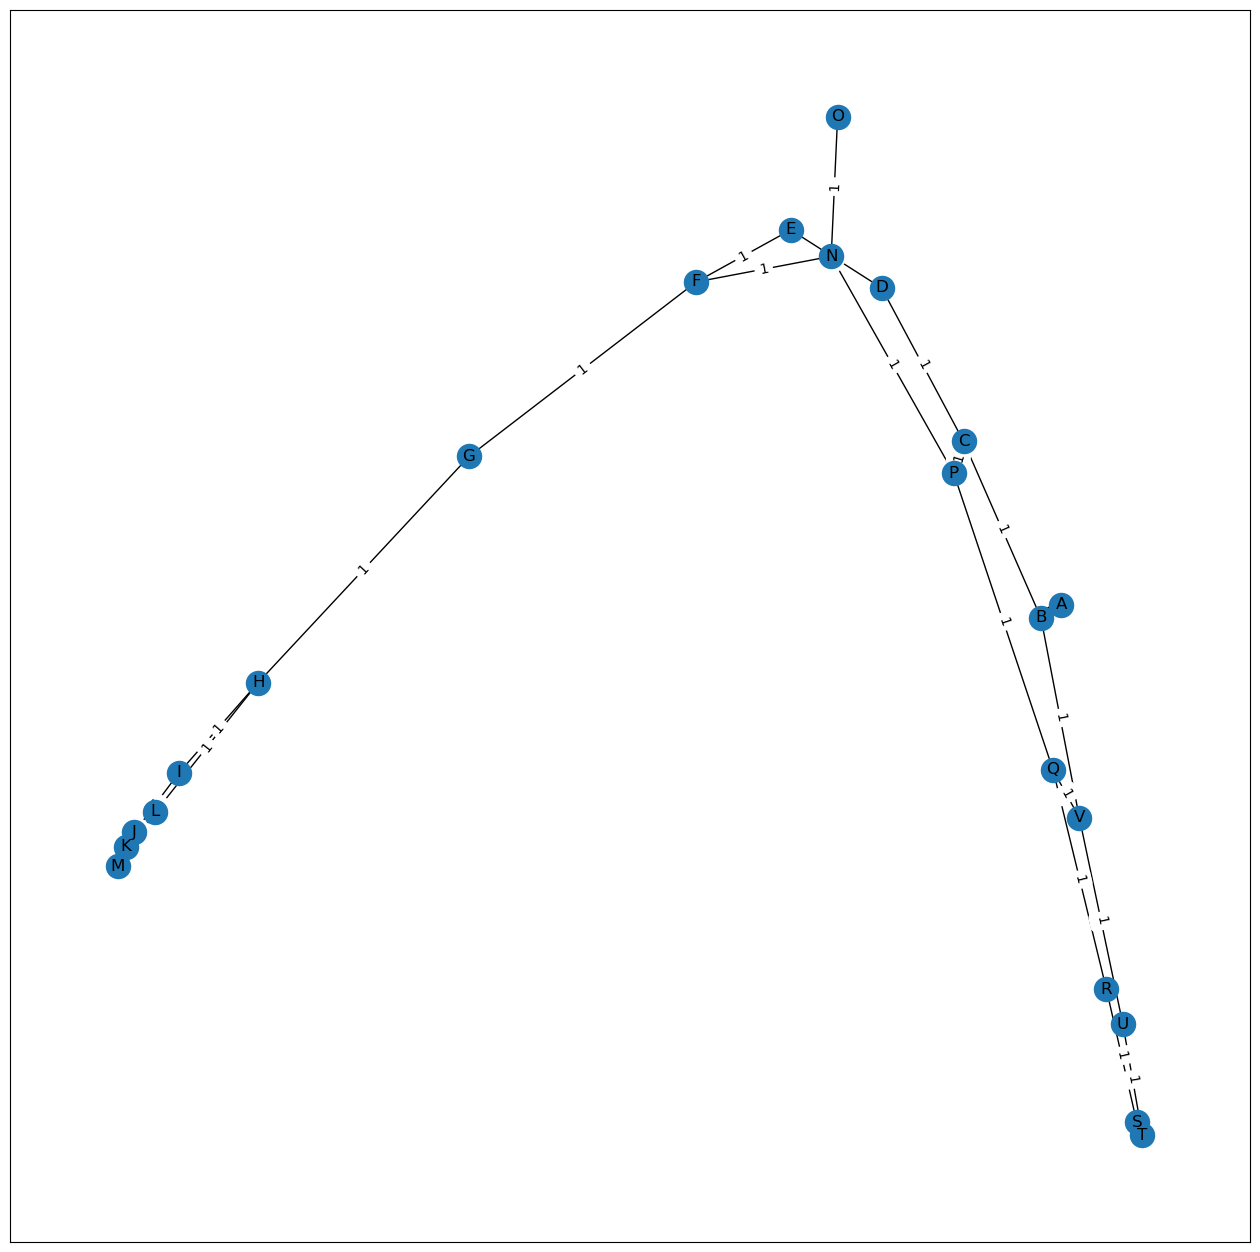

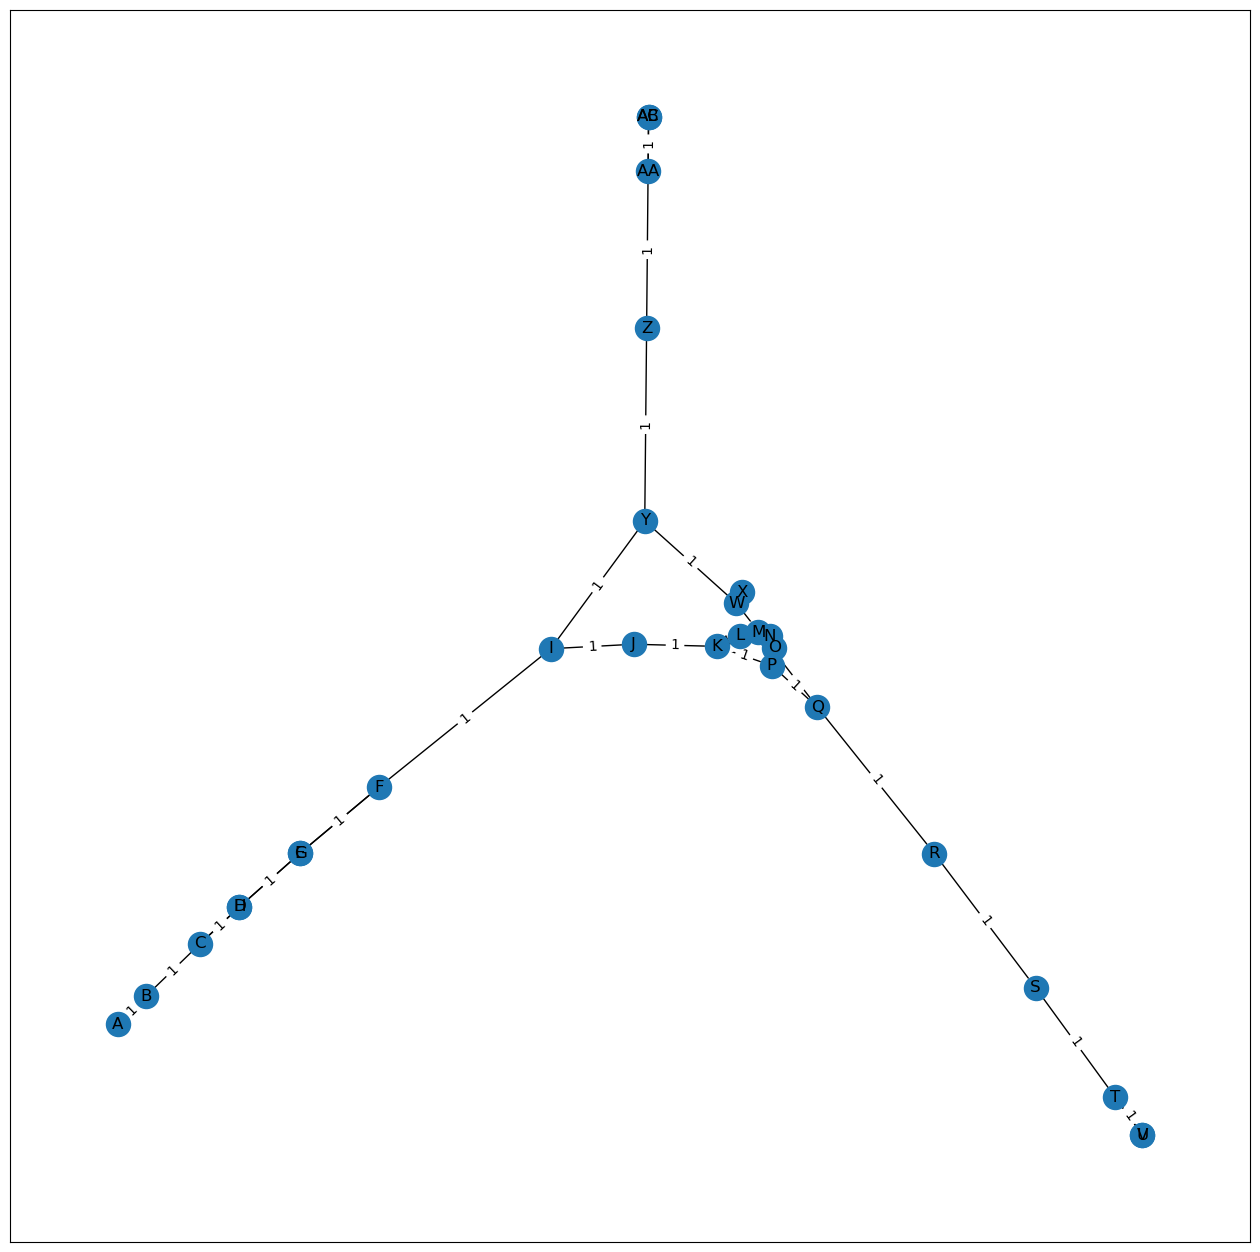

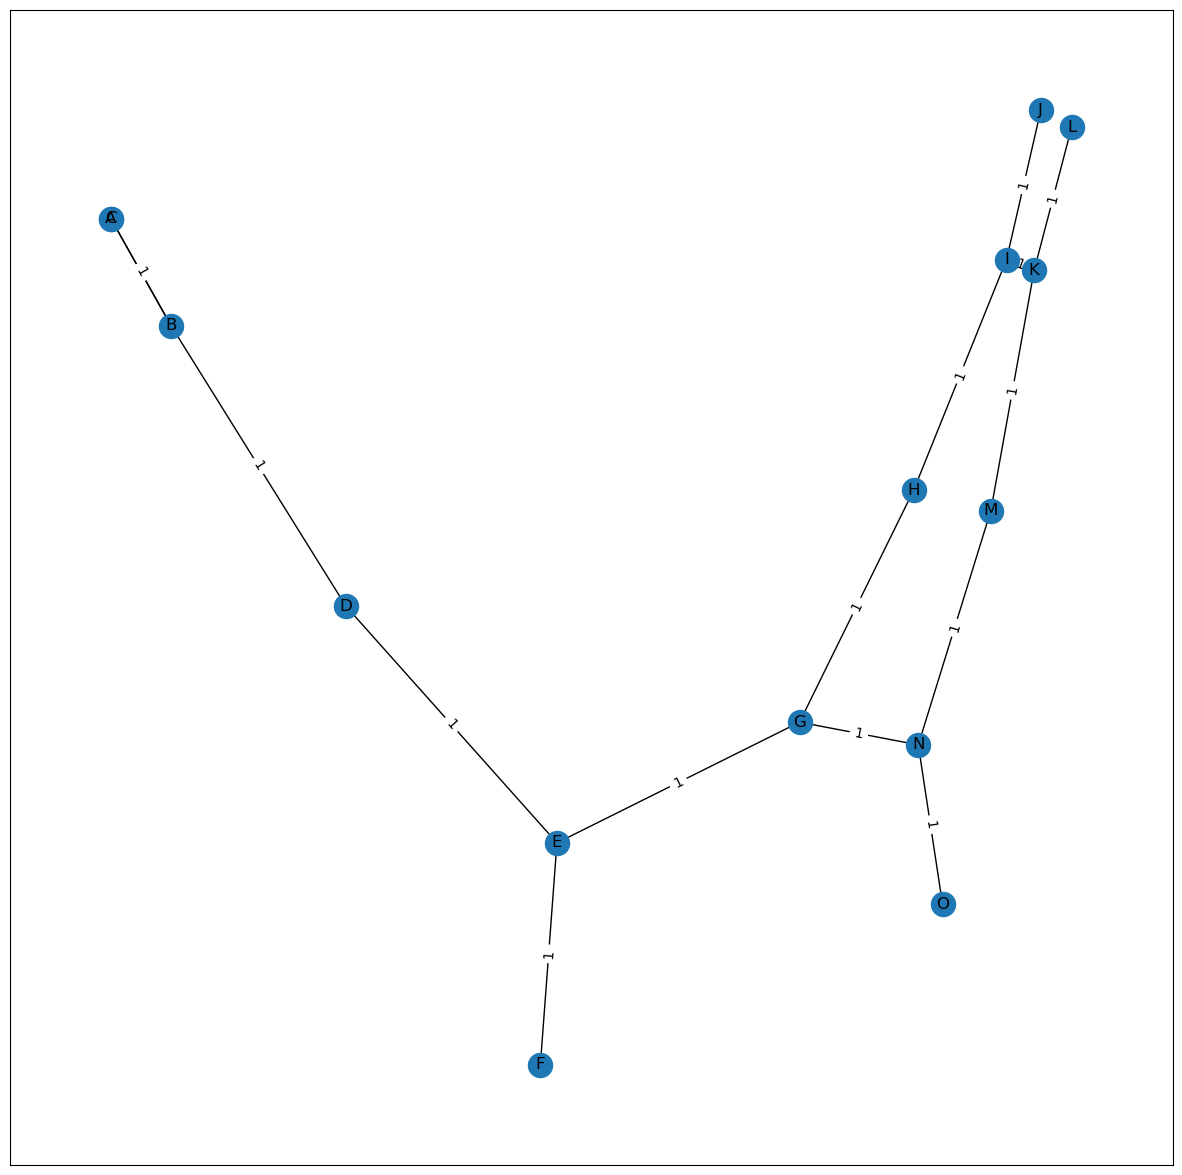

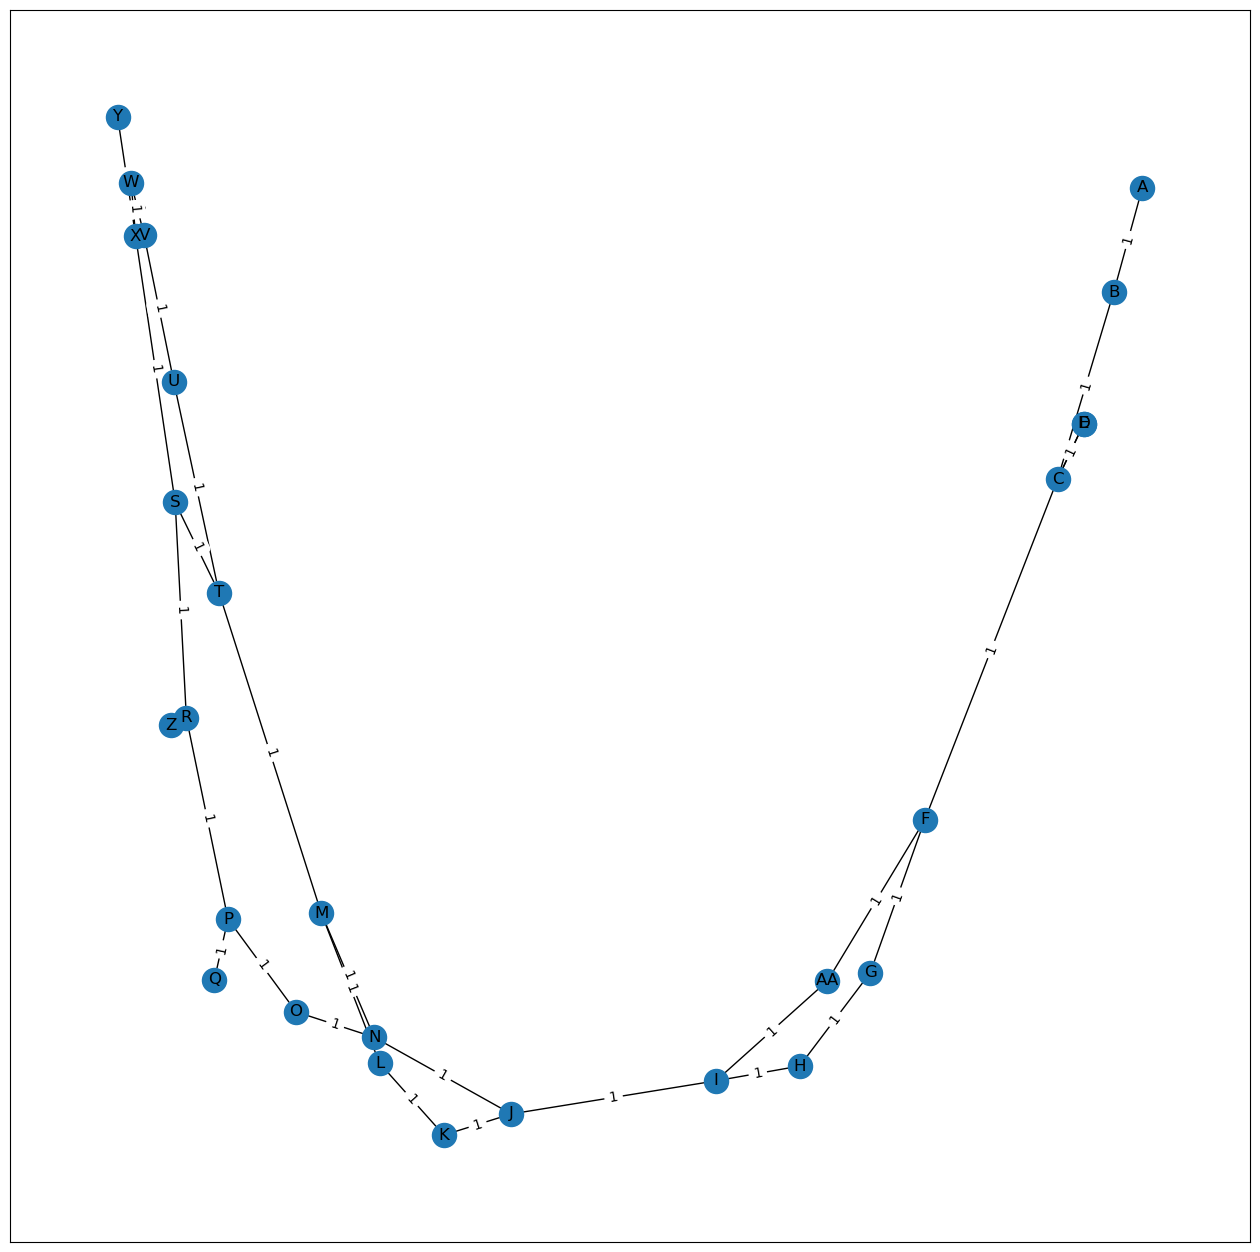

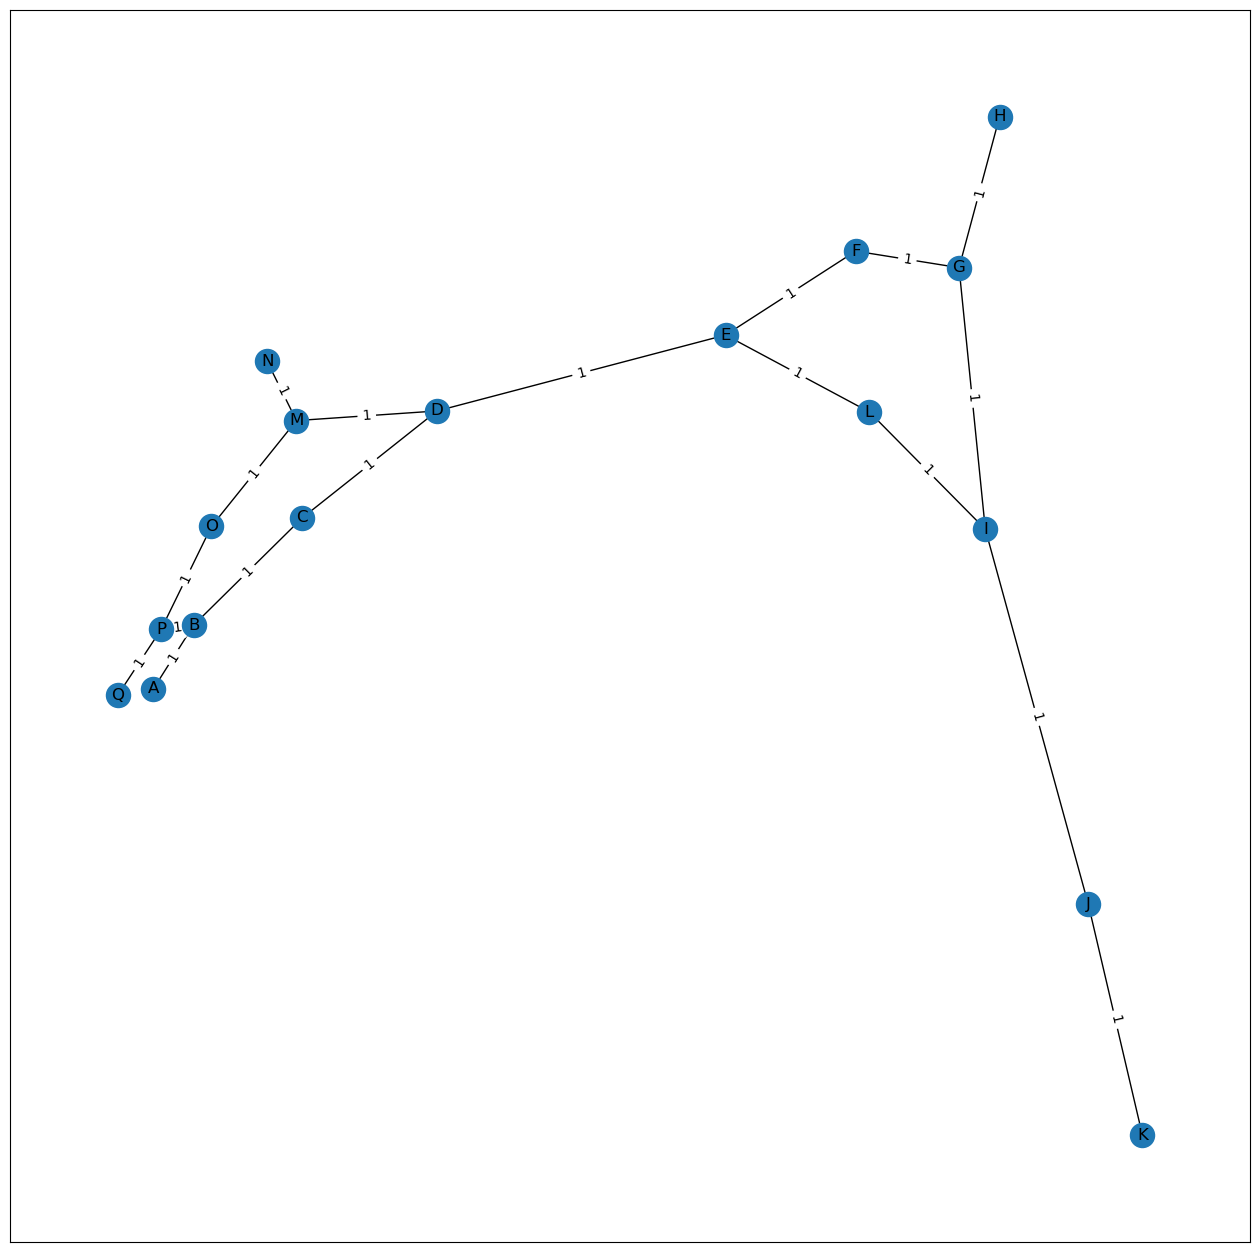

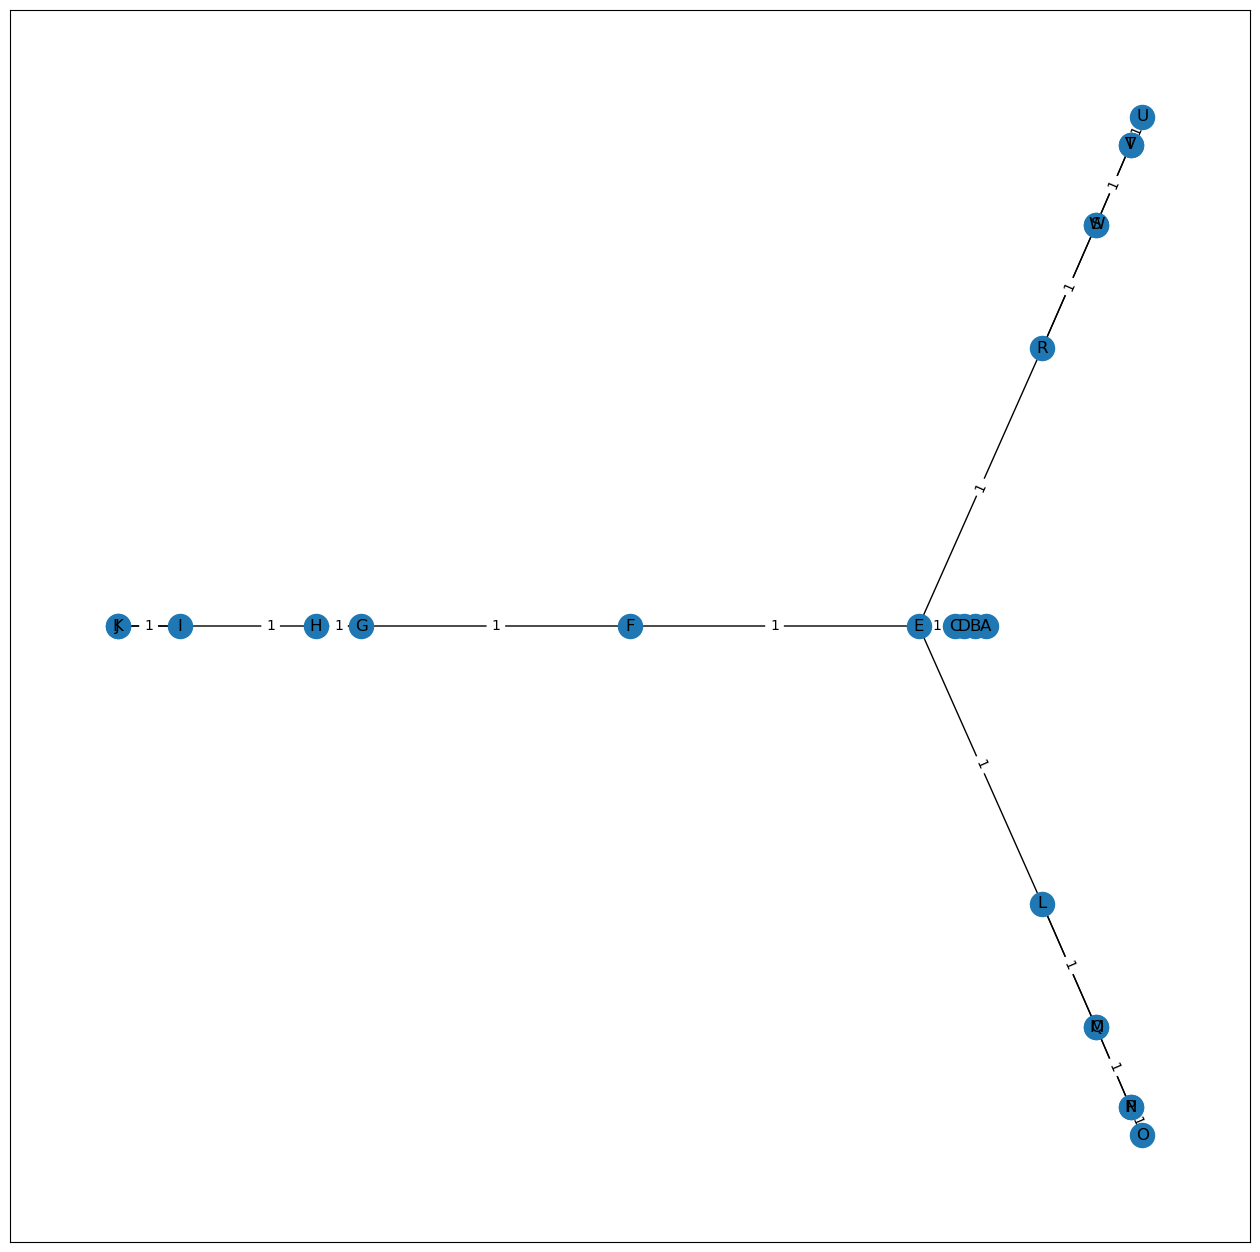

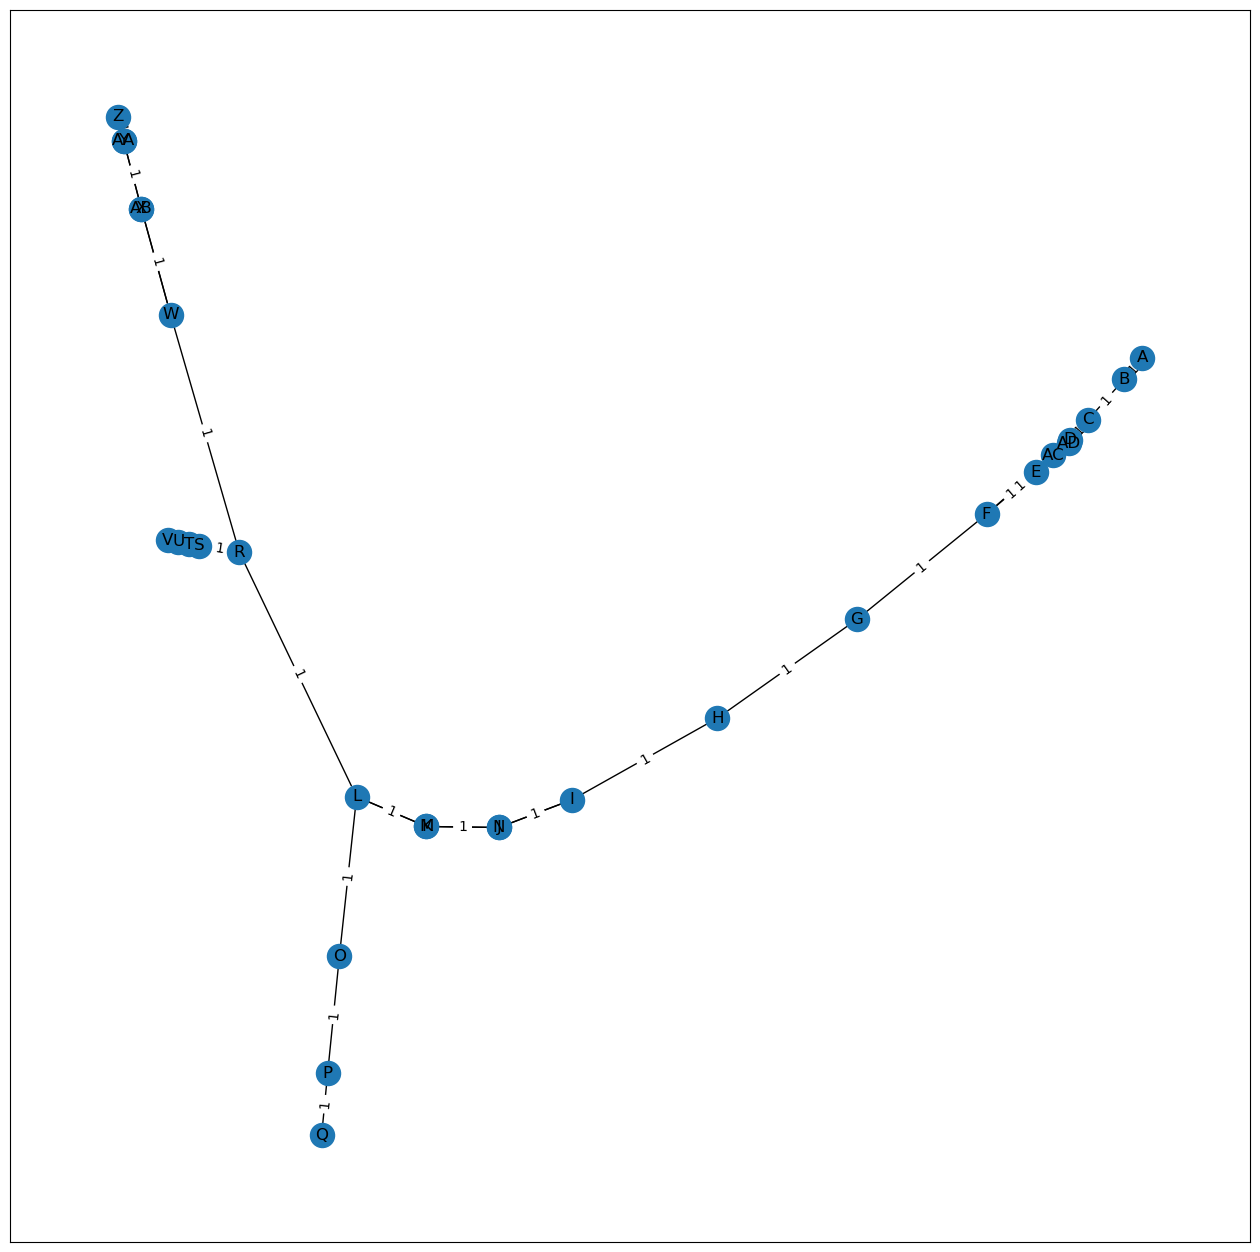

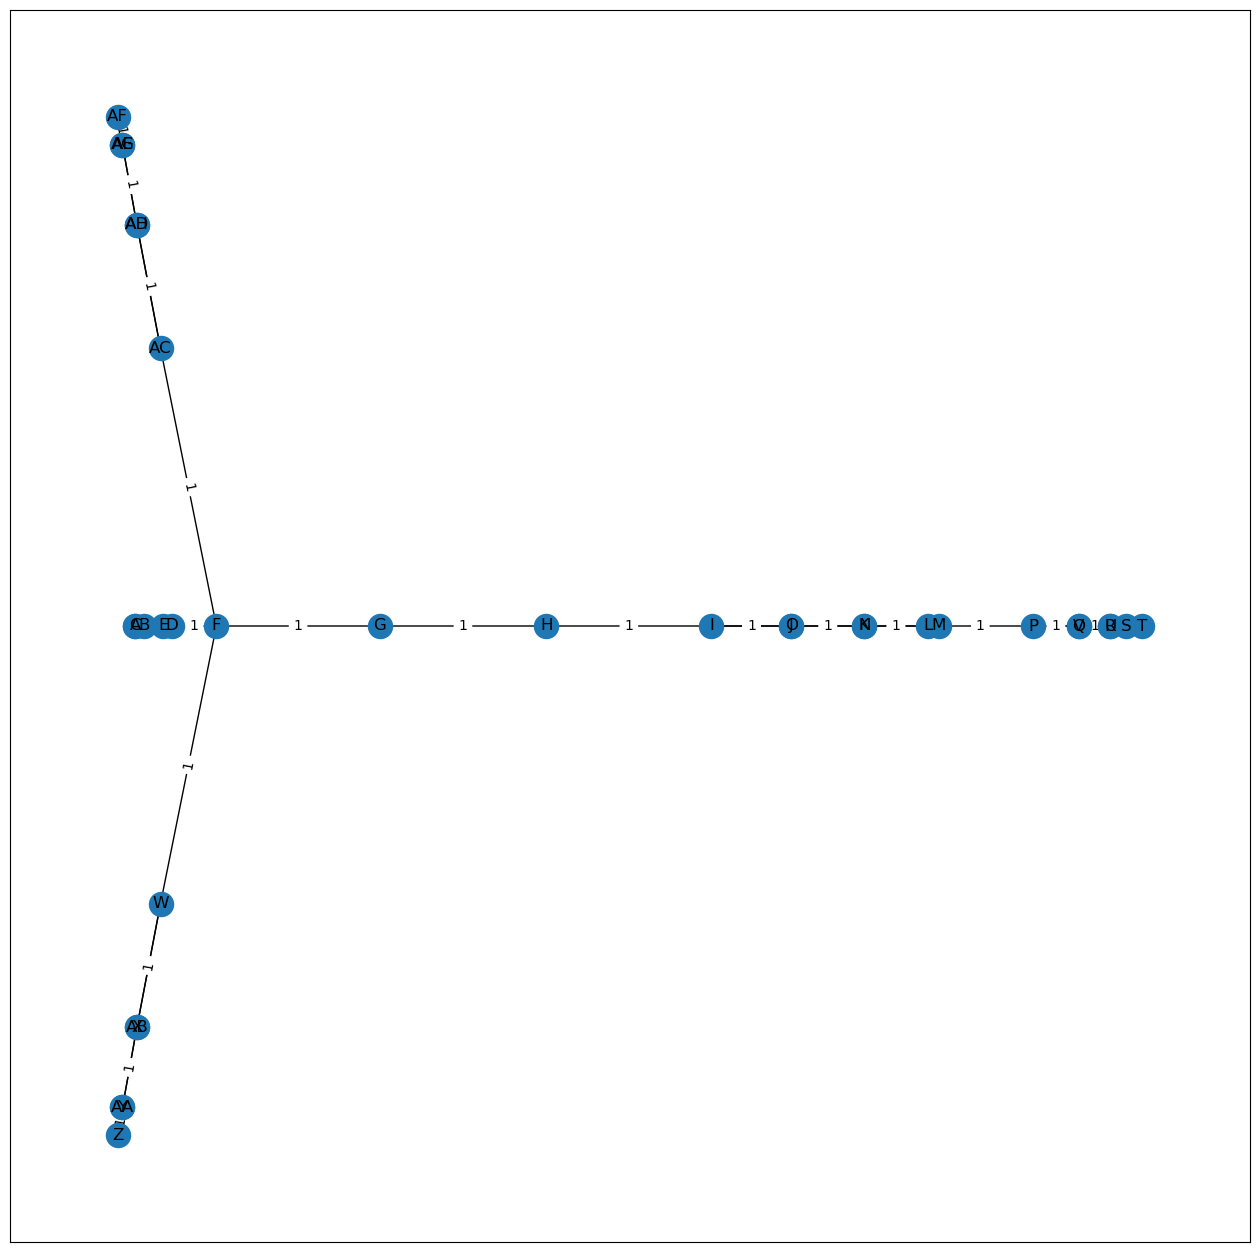

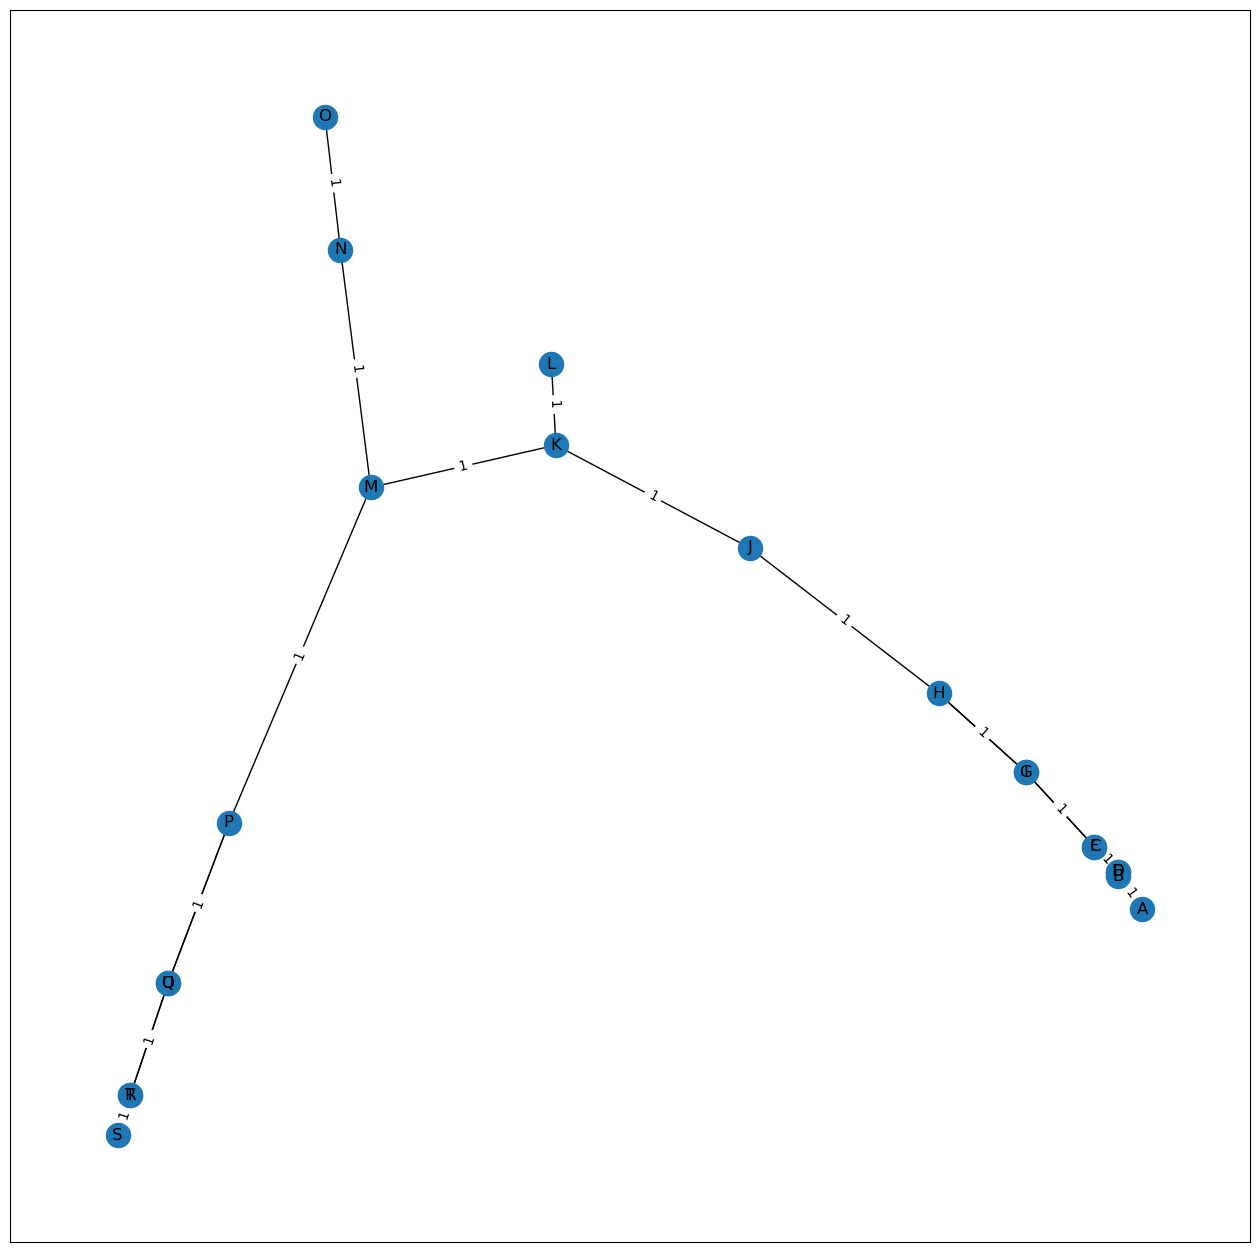

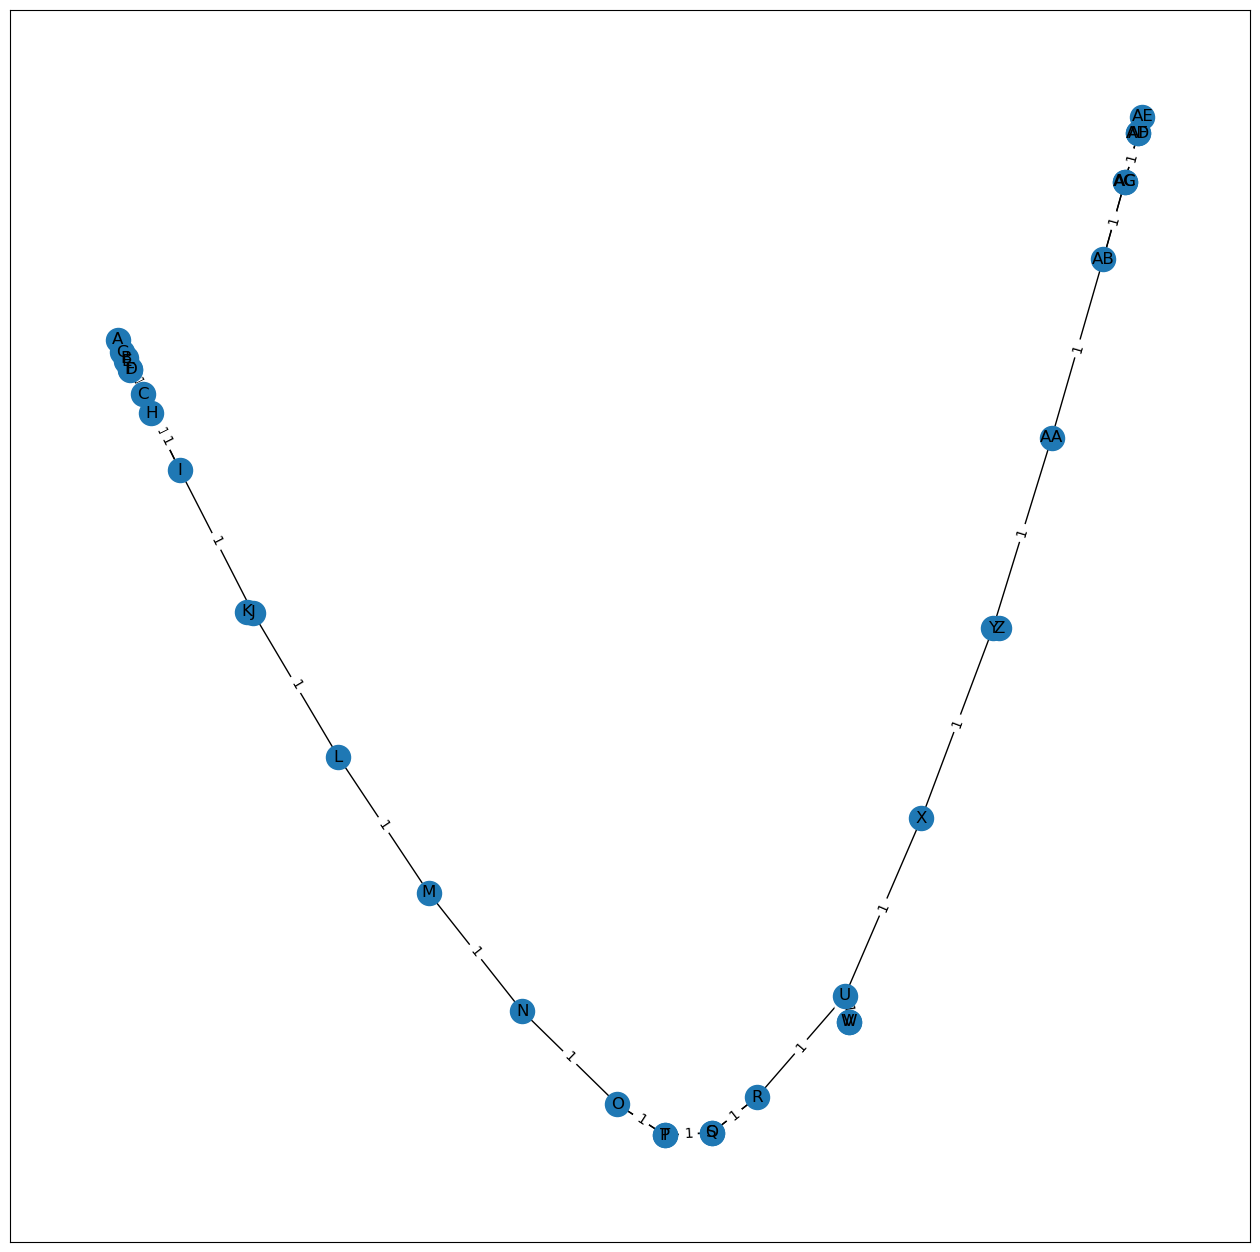

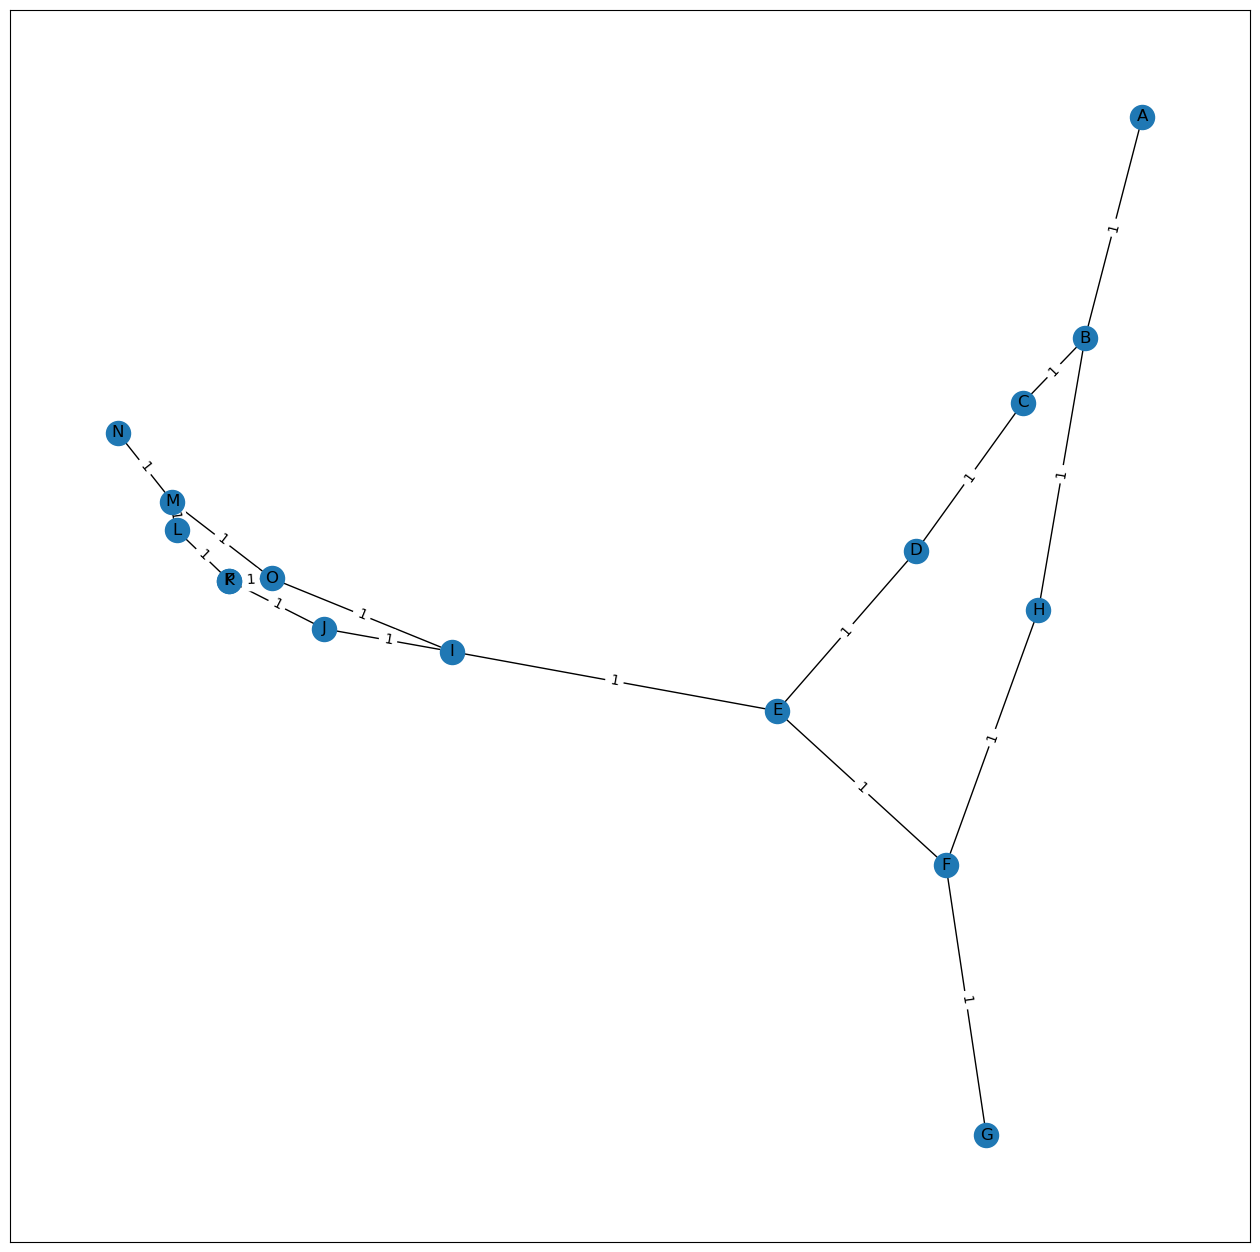

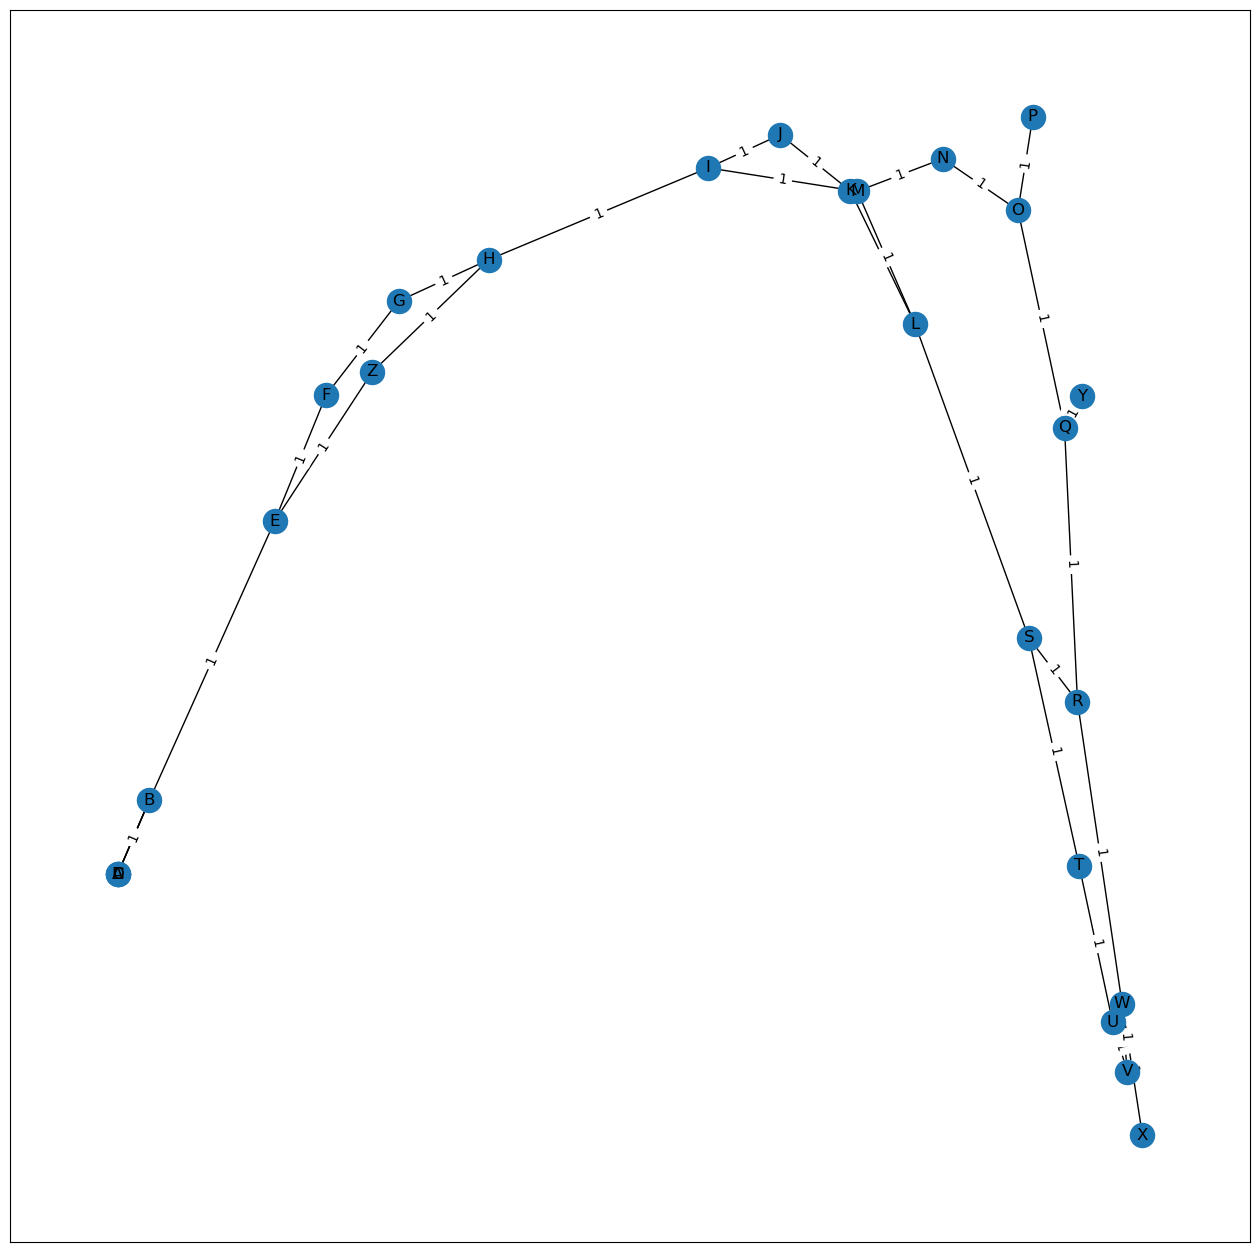

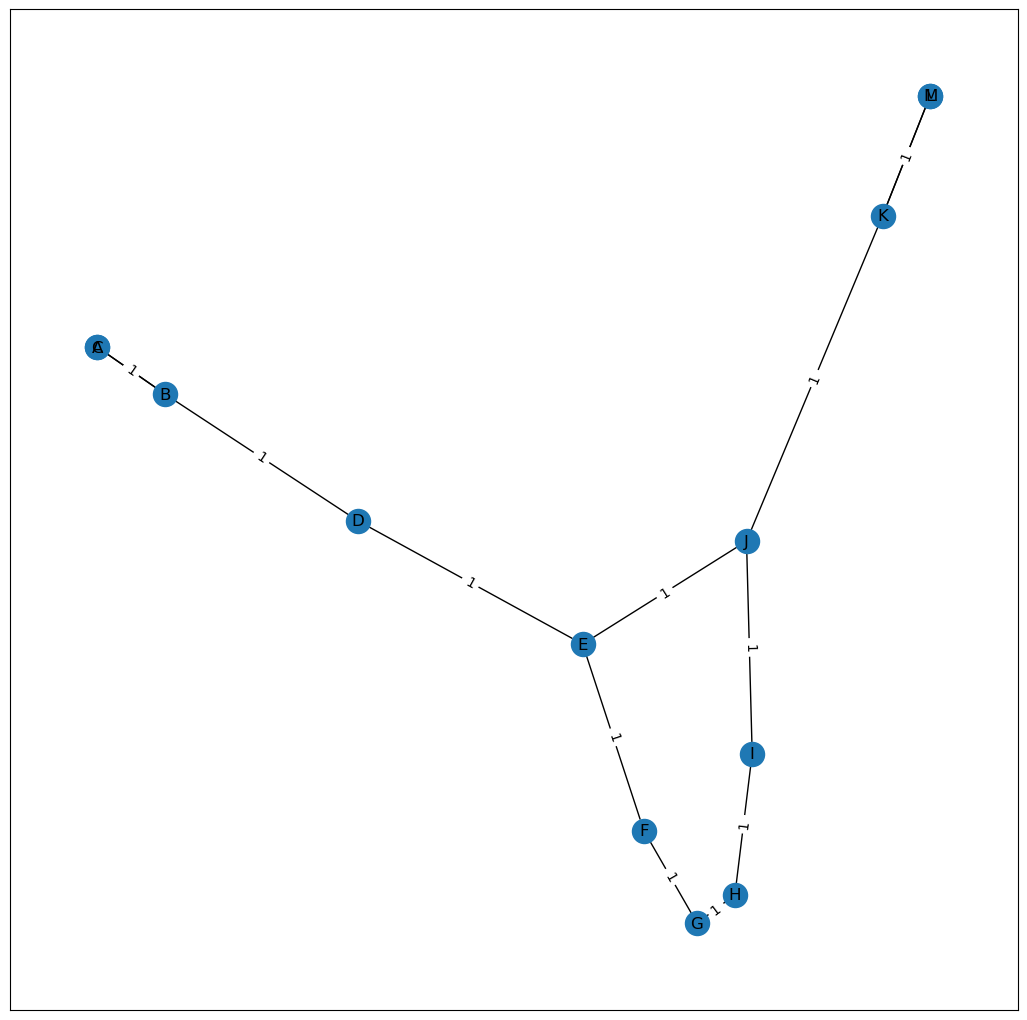

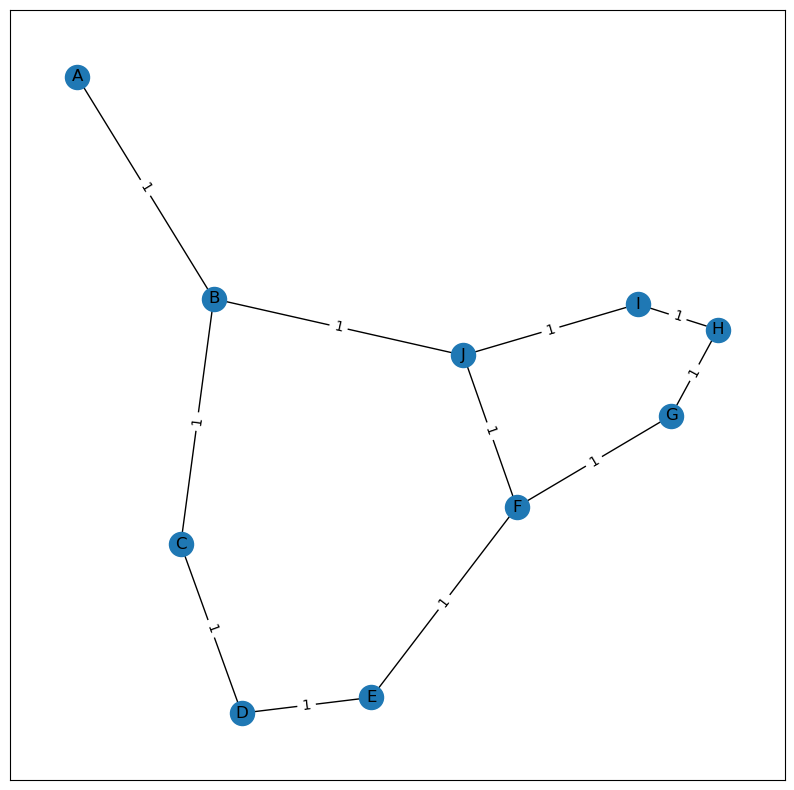

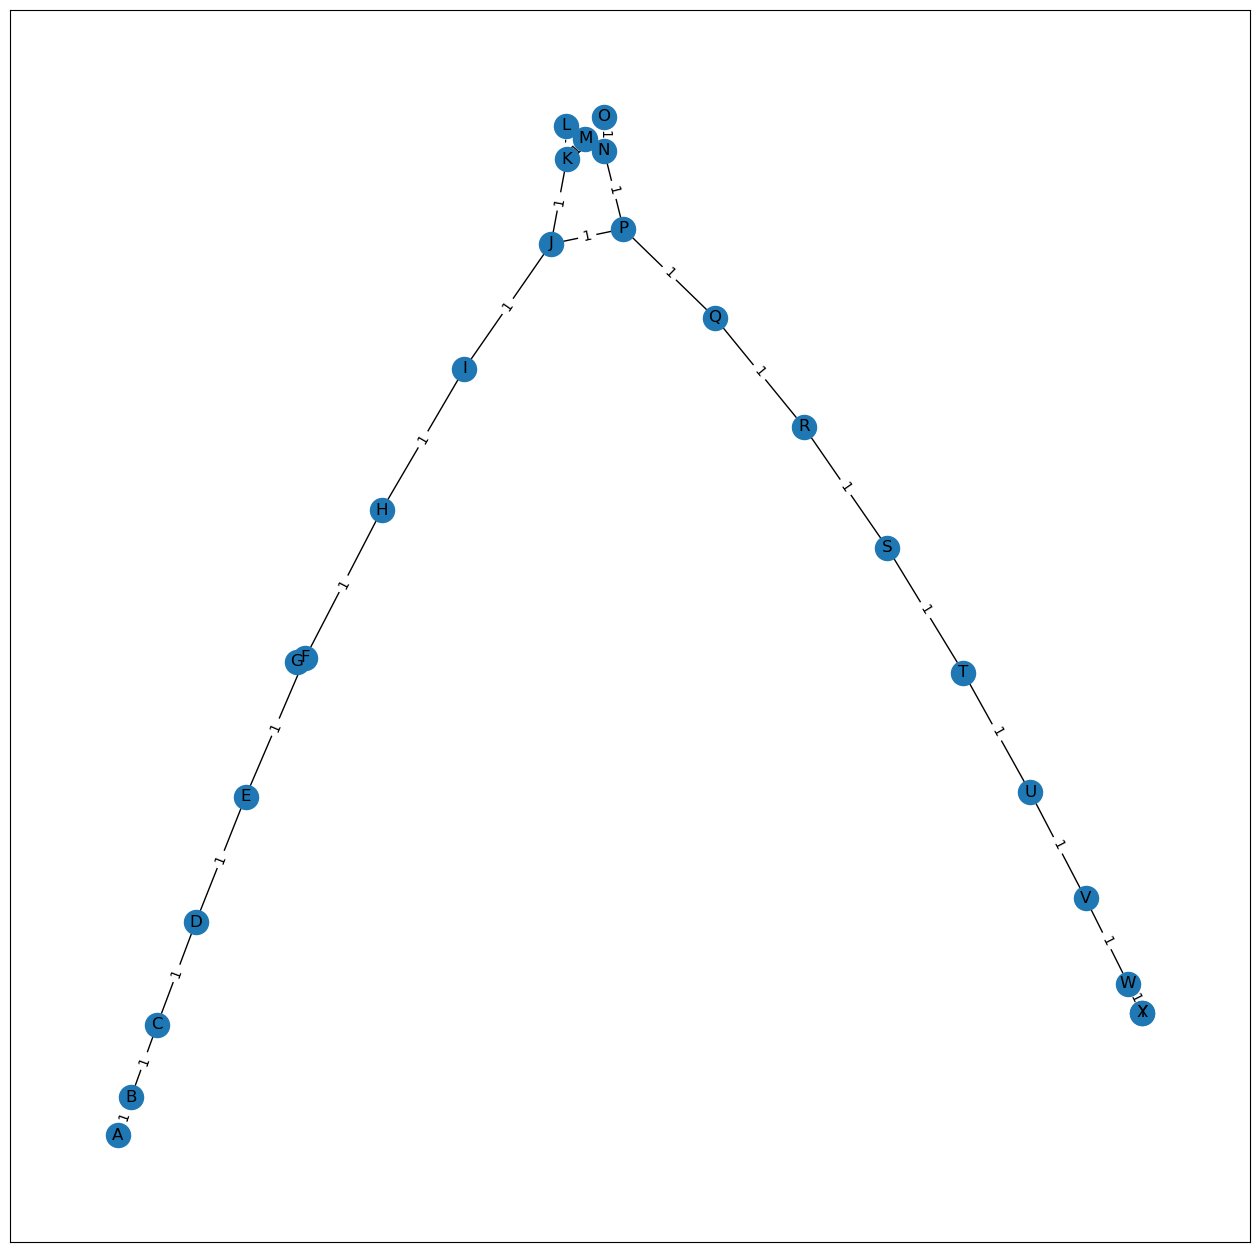

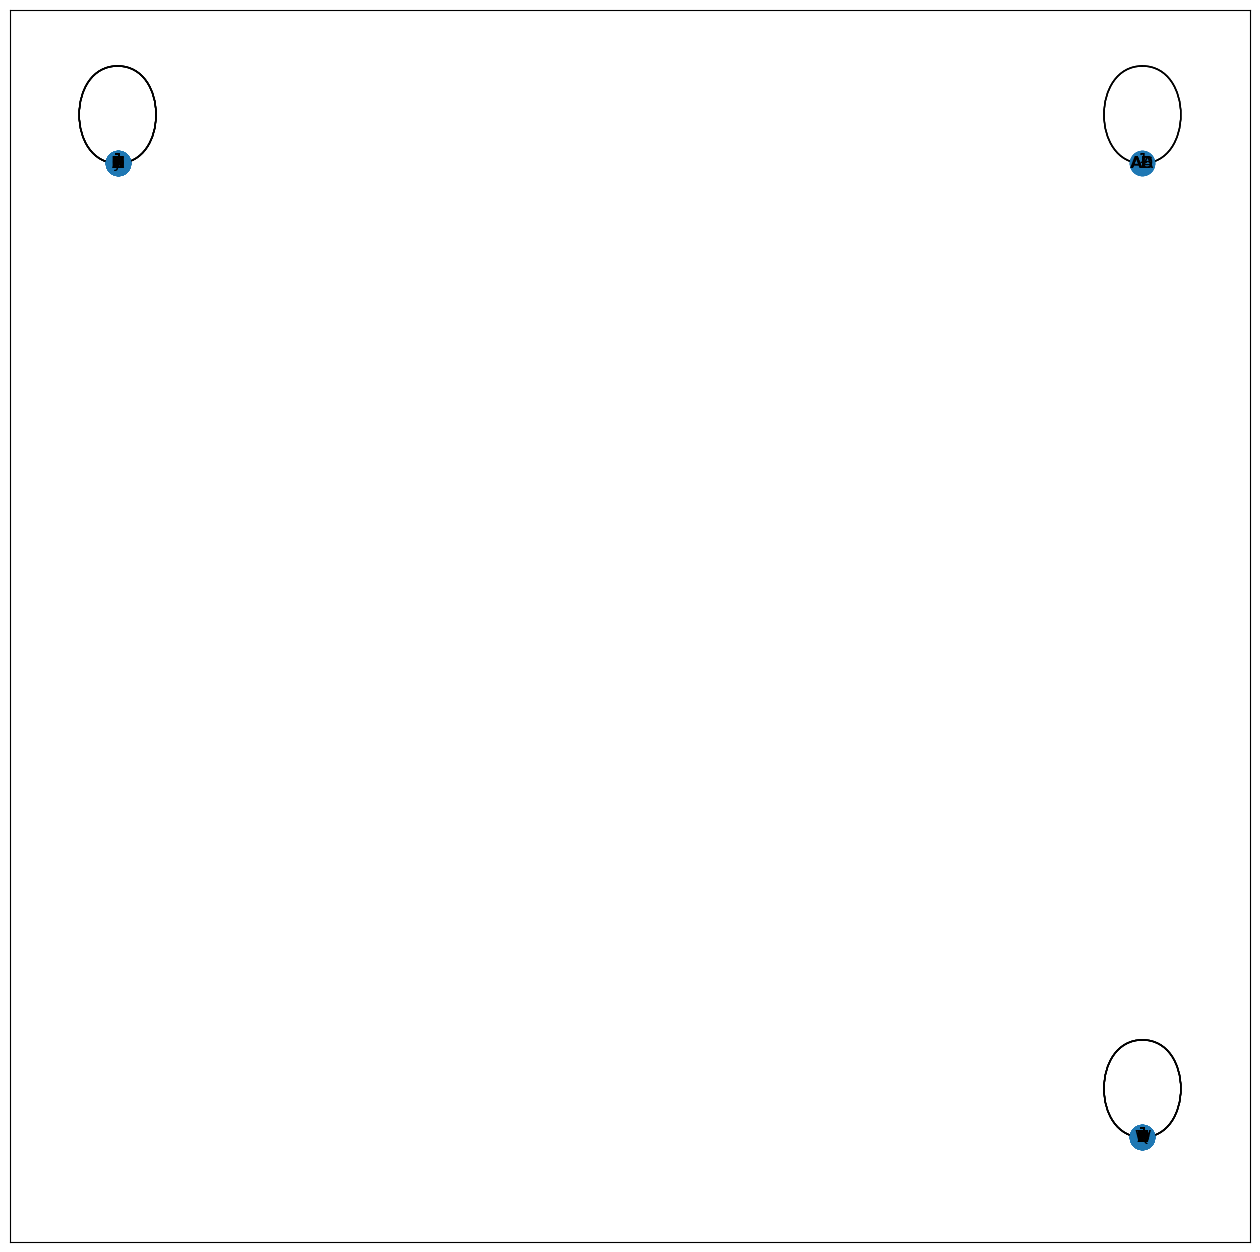

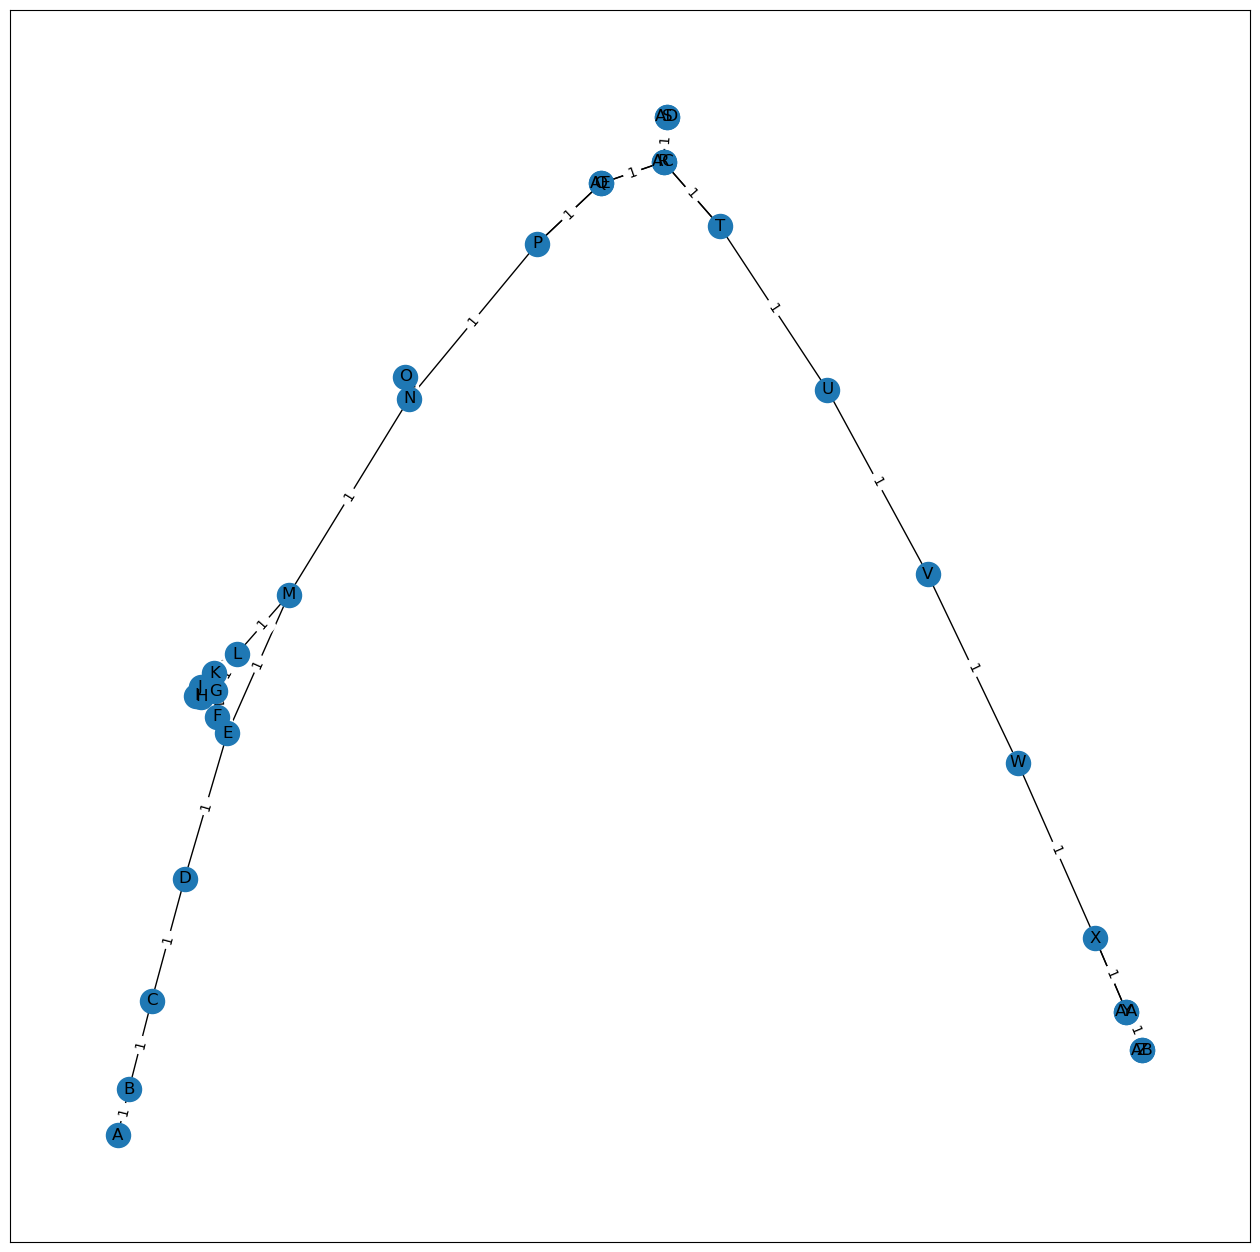

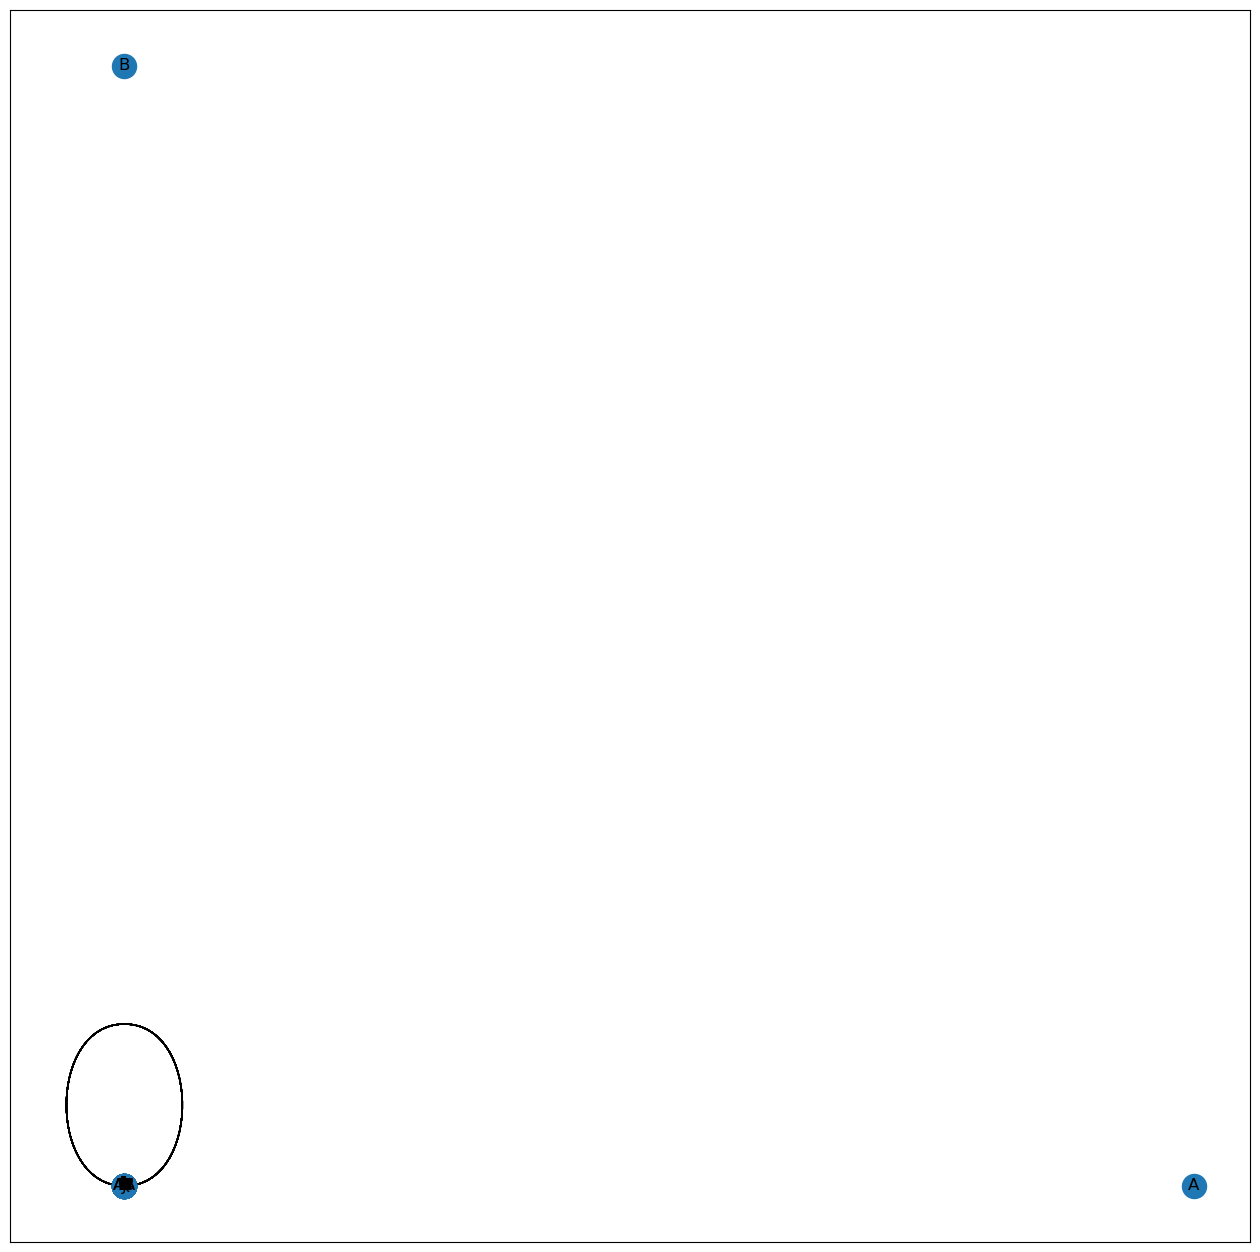

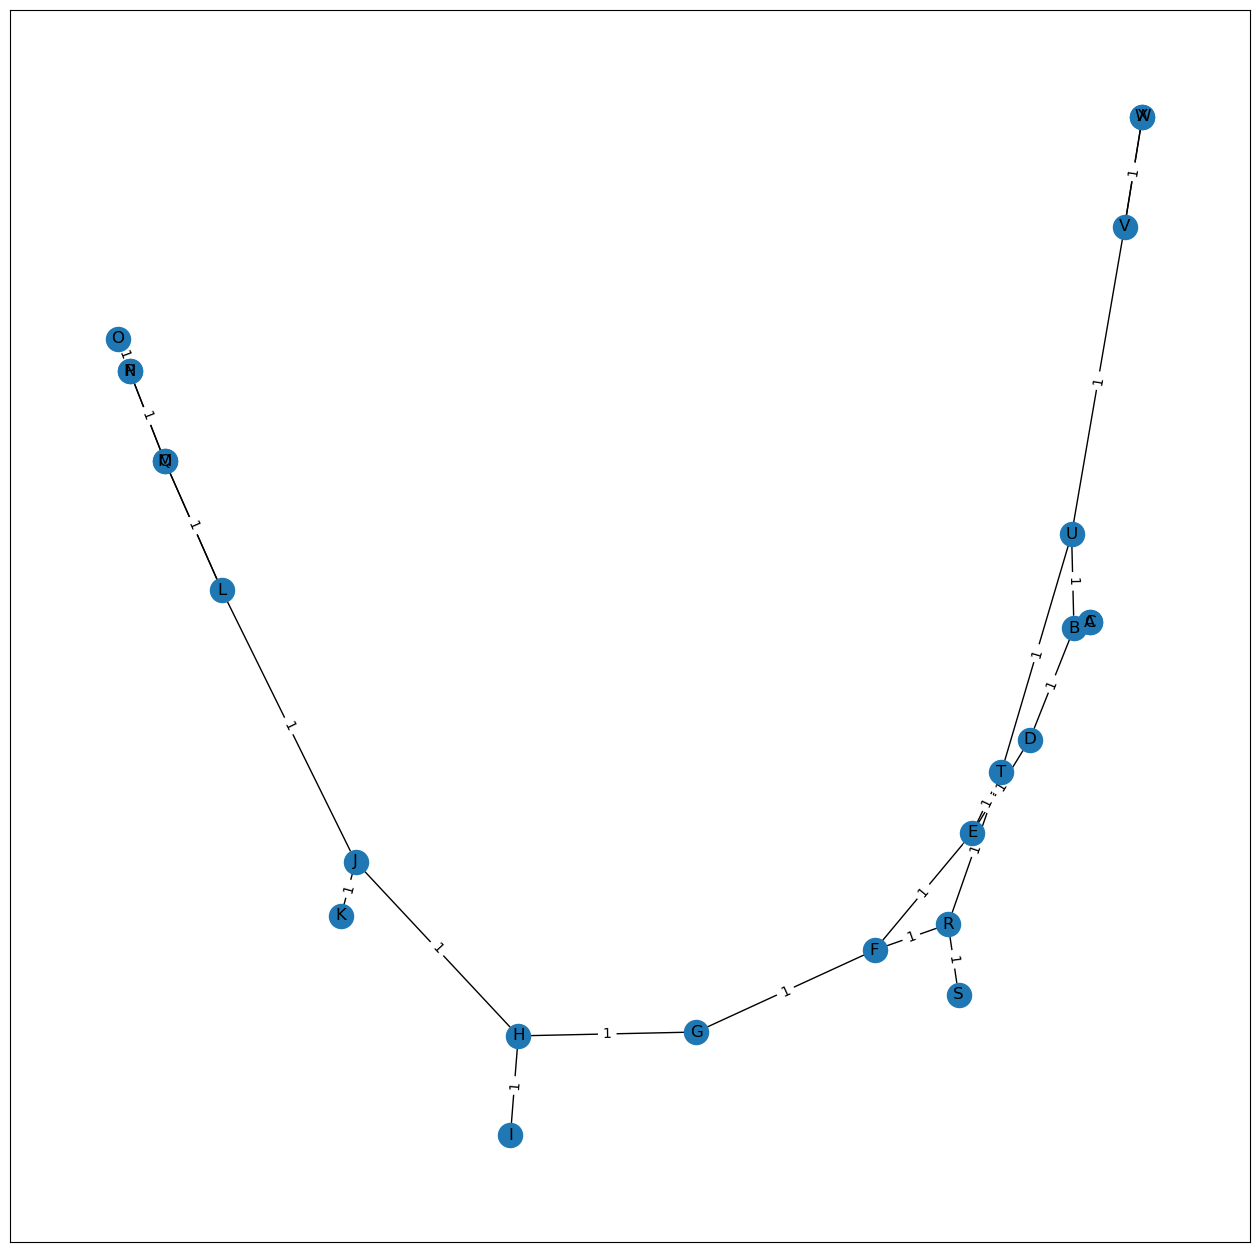

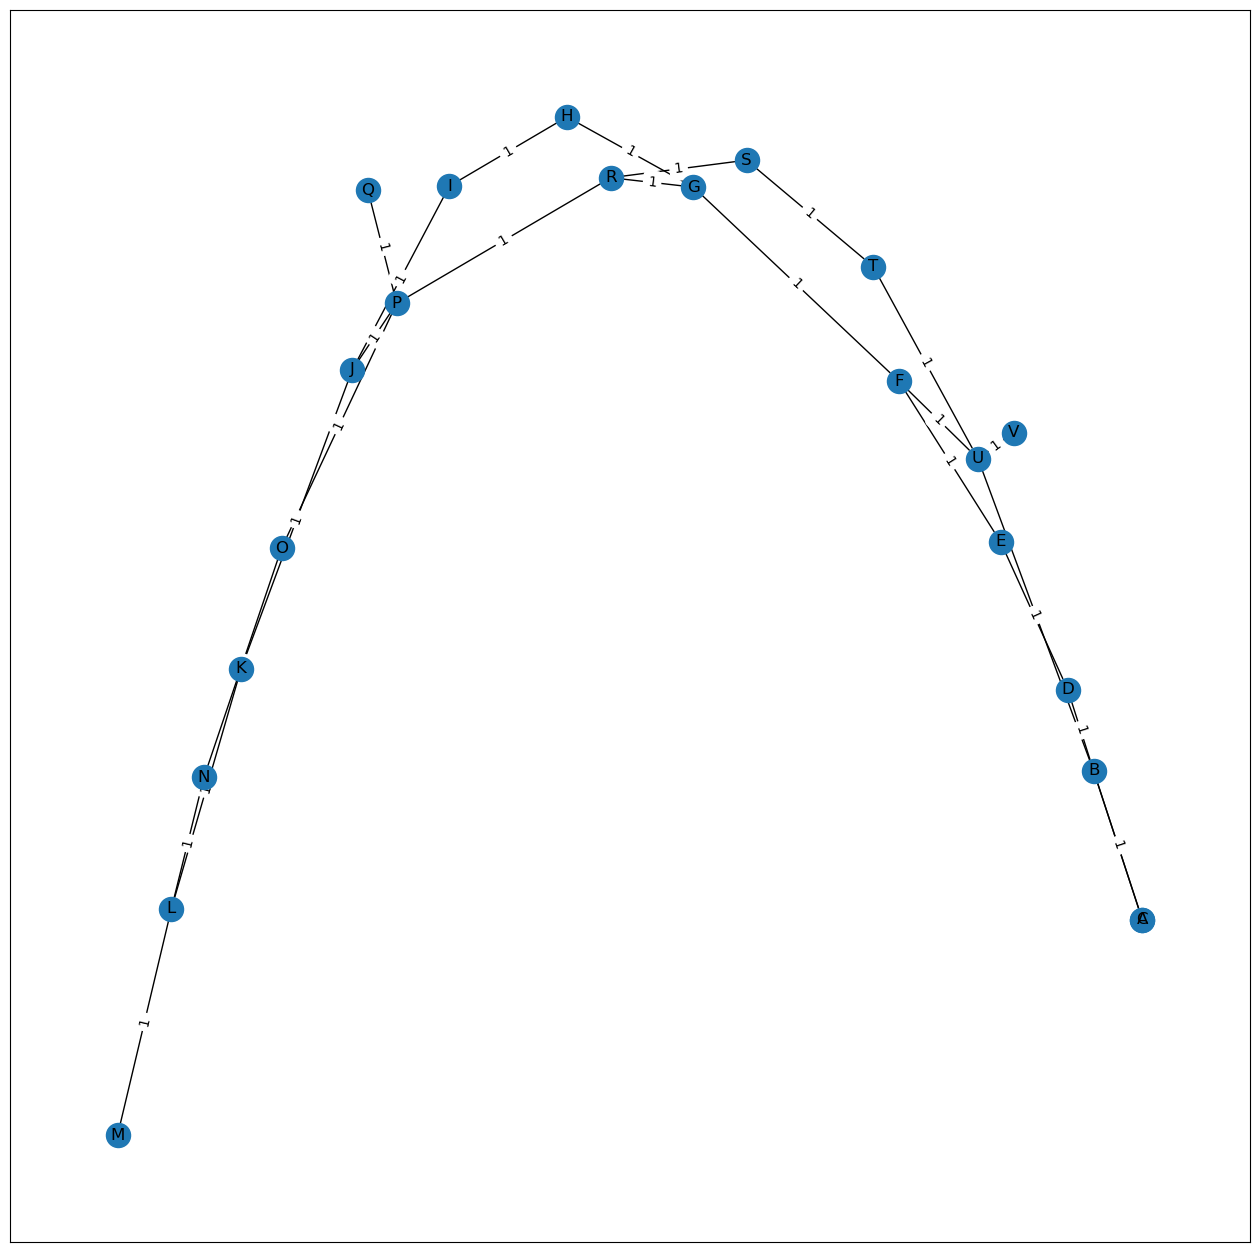

In [5]:
# Plot the graphs
for g in gs.graphs.values():
    g.plot()

## 6.Making feature vectors based on the frequency of the subgraphs

In [8]:
# Extract supgraph feature by counting supgraph k in each graph
import networkx as nx

# Initialize an empty list to store the cliques of each graph
cliques = []
num_cliques = []
# Iterate over each graph in the list
for graph in gs.graphs.values():
    # Convert gspan Graph to NetworkX graph
    gnx = nx.Graph() if graph.is_undirected else nx.DiGraph()
    for vid, v in graph.vertices.items():
        gnx.add_node(vid)
    for vid, v in graph.vertices.items():
        for to, e in v.edges.items():
            if (not graph.is_undirected) or vid < to:
                gnx.add_edge(vid, to)
    
    # Find all cliques in the current graph
    graph_cliques = list(nx.find_cliques(gnx))
    # Add the cliques to the list
    cliques.append(graph_cliques)
    # Add the number of cliques to the list
    num_cliques.append(len(graph_cliques))

# Print the cliques
for i, graph_cliques in enumerate(cliques):
    print(f'Cliques for graph{i+1}: {graph_cliques}')

Cliques for graph1: [['4', '5'], ['4', '2'], ['1', '2'], ['6', '8'], ['6', '7'], ['6', '5'], ['14', '13'], ['14', '15'], ['14', '19'], ['9', '8'], ['9', '10'], ['19', '10'], ['19', '18'], ['0'], ['12', '13'], ['12', '11'], ['17', '16'], ['17', '18'], ['2', '3'], ['10', '11'], ['16', '15']]
Cliques for graph2: [['7', '8'], ['7', '0'], ['8', '9'], ['1', '0'], ['21', '20'], ['21', '22'], ['14', '13'], ['14', '15'], ['9', '10'], ['19', '18'], ['0', '2'], ['12', '13'], ['12', '11'], ['17', '16'], ['17', '18'], ['13', '16'], ['10', '15'], ['10', '11'], ['3', '4'], ['3', '5'], ['3', '2'], ['3', '6'], ['20', '16']]
Cliques for graph3: [['4', '8'], ['4', '5'], ['4', '3'], ['2', '1'], ['2', '3'], ['0', '1'], ['0', '5'], ['7', '8'], ['7', '9'], ['7', '6'], ['10', '9'], ['10', '11'], ['6', '5']]
Cliques for graph4: [['4', '12'], ['4', '5'], ['4', '3'], ['7', '8'], ['7', '6'], ['24', '16'], ['24', '25'], ['24', '23'], ['26', '28'], ['26', '27'], ['26', '22'], ['8', '9'], ['1', '12'], ['1', '2'], ['

## 7. Simple regressions based on graph features: cliques

In [10]:
import numpy as np

print(num_cliques)

num_cliques_1 = np.array(num_cliques).reshape(-1, 1)

print(num_cliques_1)
print(num_cliques_1.shape)

[21, 23, 13, 32, 48, 42, 25, 31, 15, 30, 18, 24, 32, 37, 23, 35, 17, 29, 13, 11, 25, 31, 33, 30, 26, 25]
[[21]
 [23]
 [13]
 [32]
 [48]
 [42]
 [25]
 [31]
 [15]
 [30]
 [18]
 [24]
 [32]
 [37]
 [23]
 [35]
 [17]
 [29]
 [13]
 [11]
 [25]
 [31]
 [33]
 [30]
 [26]
 [25]]
(26, 1)


In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from rdkit import Chem
import networkx as nx
from rdkit.Chem import rdmolops

# Load the CSV file
df = pd.read_csv('./graphdata/Molecular_Sample.csv')

label = df['p_np']
smiles = df['smiles']
print(label)
print(smiles)

0     1
1     1
2     0
3     1
4     1
5     1
6     1
7     1
8     1
9     0
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
Name: p_np, dtype: int64
0                      [Cl].CC(C)NCC(O)COc1cccc2ccccc12
1              C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2                                    c1cccn2c1nc(c2)CCN
3     Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...
4     CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(...
5     CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@...
6                   Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14
7     COc1ccc(cc1)[C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@...
8                          NC(N)=NC(=O)c1nc(Cl)c(N)nc1N
9       OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1
10        CC1=CN([C@H]2C[C@H](F)[C@@H](CO)O2)C(=O)NC1=O
11               CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c2ccccc2
12    CCN1N=NN(CCN2CCC(CC2)(COC)N(C(=O)CC)c3ccccc3)C1=O
13    CN(C)C(=O)C(CCN1CCC(O)(CC1)c1ccc(

In [13]:
print(len(gs.graphs))

26


In [17]:
# Initialize X and Y as empty lists
X = []
Y = []

# Iterate over each graph ID and its number of cliques
for gid, num_clique in zip(sorted(gs.graphs.keys()), num_cliques):
    # Store the graph and its number of cliques in X
    X.append([smiles[gid], num_clique])
    
    # Store the label of the current graph in Y
    Y.append(label[gid])

In [18]:
print('X:', X)
print('Y:', Y)


X: [['[Cl].CC(C)NCC(O)COc1cccc2ccccc12', 21], ['C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl', 23], ['c1cccn2c1nc(c2)CCN', 13], ['Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O', 32], ['CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O', 48], ['CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@@]3(C)O)C(=O)[C@]2(O)C(=O)\\C(=C(/O)NCN5CCCC5)C1=O', 42], ['Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14', 25], ['COc1ccc(cc1)[C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@H]2OC(C)=O', 31], ['NC(N)=NC(=O)c1nc(Cl)c(N)nc1N', 15], ['OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1', 30], ['CC1=CN([C@H]2C[C@H](F)[C@@H](CO)O2)C(=O)NC1=O', 18], ['CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c2ccccc2', 24], ['CCN1N=NN(CCN2CCC(CC2)(COC)N(C(=O)CC)c3ccccc3)C1=O', 32], ['CN(C)C(=O)C(CCN1CCC(O)(CC1)c1ccc(Cl)cc1)(c1ccccc1)c1ccccc1', 37], ['CN1C2CCC1CC(C2)OC(=O)[C@H](CO)c3ccccc3', 23], ['COc1ccc(Cl)cc1C(=O)NCCc2ccc(cc2)[S](=O)(=O)NC(=O)NC3CCCCC3', 35], ['Nc1nnc(c(N)n1)c2cccc(Cl)c2Cl', 17], [

In [19]:
from sklearn import svm
regr = svm.SVR()

In [21]:
# Prepare feature matrix and target vector
import numpy as np
import pandas as pd

# Initialize feature matrix (X) and target vector (Y)
X = []  # Feature matrix: [number of cliques] for each graph
Y = []  # Target vector: property values for each graph

# Build feature matrix by iterating through graphs and their clique counts
for graph_index, (graph, num_clique) in enumerate(zip(gs.graphs, num_cliques)):
    # Each sample is a 1D feature: the number of cliques in the graph
    X.append([num_clique])
    
    # Corresponding target is the property value from the CSV
    Y.append(label.iloc[graph_index])

# Convert lists to numpy arrays for scikit-learn compatibility
X = np.array(X, dtype=float)
Y = np.array(Y, dtype=float)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {Y.shape}")
print(f"\nFirst 5 features (clique counts):\n{X[:5]}")
print(f"\nFirst 5 targets (property values):\n{Y[:5]}")

Feature matrix shape: (26, 1)
Target vector shape: (26,)

First 5 features (clique counts):
[[21.]
 [23.]
 [13.]
 [32.]
 [48.]]

First 5 targets (property values):
[1. 1. 0. 1. 1.]


In [22]:
print('X:', X)
print('Y:', Y)

X: [[21.]
 [23.]
 [13.]
 [32.]
 [48.]
 [42.]
 [25.]
 [31.]
 [15.]
 [30.]
 [18.]
 [24.]
 [32.]
 [37.]
 [23.]
 [35.]
 [17.]
 [29.]
 [13.]
 [11.]
 [25.]
 [31.]
 [33.]
 [30.]
 [26.]
 [25.]]
Y: [1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [26]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# 1. Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducible results
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set size: {xtrain.shape[0]}")
print(f"Testing set size: {xtest.shape[0]}")

# 2. Scale features for better SVR performance
# SVR is sensitive to feature scaling, so standardization improves accuracy
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

# 3. Hyperparameter tuning with GridSearchCV
# Test different kernels and regularization parameters for optimal accuracy
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

svr_base = SVR()
grid_search = GridSearchCV(svr_base, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
print("\nTuning hyperparameters... (this may take a moment)")
grid_search.fit(xtrain_scaled, ytrain)

# 4. Get the best model and print results
svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\nBest hyperparameters: {best_params}")
print(f"Best cross-validation R² score: {best_cv_score:.4f}")
print(f"Best model support vectors count: {len(svr_model.support_vectors_)}")

Training set size: 20
Testing set size: 6

Tuning hyperparameters... (this may take a moment)
Fitting 5 folds for each of 60 candidates, totalling 300 fits



Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation R² score: -0.7458
Best model support vectors count: 17


MODEL PERFORMANCE METRICS
Mean Squared Error (MSE):  0.0815
Root Mean Squared Error (RMSE): 0.2855
Mean Absolute Error (MAE): 0.2451
R² Score: 0.6333
Training R² Score: 0.4897


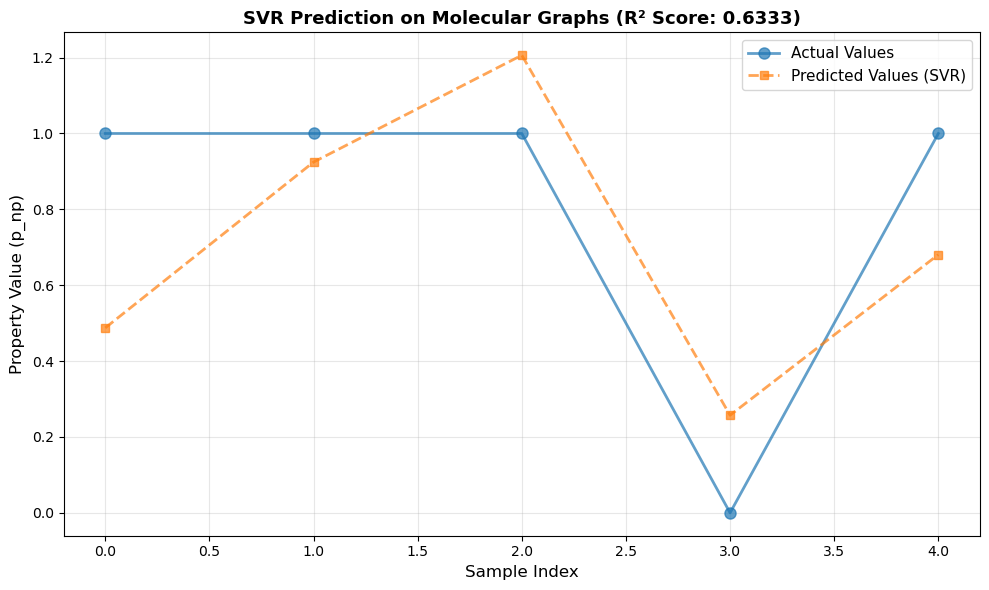

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Generate predictions on scaled test set
ypred = svr_model.predict(xtest_scaled)

# 2. Calculate multiple evaluation metrics
mse = mean_squared_error(ytest, ypred)
rmse = mse ** 0.5  # Root Mean Squared Error
mae = mean_absolute_error(ytest, ypred)
r2 = r2_score(ytest, ypred)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Training R² Score: {svr_model.score(xtrain_scaled, ytrain):.4f}")
print("=" * 50)

# 4. Visualize predictions vs actual values (first 4 samples)
num_samples = 5
x_axis = range(num_samples)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, ytest[:num_samples], 'o-', label='Actual Values', linewidth=2, markersize=8, alpha=0.7)
plt.plot(x_axis, ypred[:num_samples], 's--', label='Predicted Values (SVR)', linewidth=2, markersize=6, alpha=0.7)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Property Value (p_np)', fontsize=12)
plt.title(f"SVR Prediction on Molecular Graphs (R² Score: {r2:.4f})", fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h3><center><b>💻🎉 CONGRATULATIONS! 🎉 </b> </center></h1>
<h4><center>You have finished your exercise! 🌟 Keep up the good work!</center></h2>